In [23]:
import os
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'
os.environ['PYTHONHASHSEED'] = '0'  # ADD THIS

import random, numpy as np, tensorflow as tf
seed = 42
random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)


In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dropout, Dense, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [25]:
import tensorflow as tf
print(tf.__version__)


2.20.0


In [26]:
import time
import os
import pickle
import numpy as np

# ---------- Size helpers ----------

def get_pickle_size_mb(obj) -> float:
    data = pickle.dumps(obj)
    return len(data) / (1024 ** 2)

def get_keras_model_size_mb(model, filename="temp_lstm_model.keras") -> float:
    model.save(filename)
    size_mb = os.path.getsize(filename) / (1024 ** 2)
    os.remove(filename)
    return size_mb

# ---------- FLOPs helpers (same style as paper) ----------

def compute_lstm_flops(model, seq_length: int, n_samples: int):
    """
    Approx FLOPs:
      per-sample ≈ 2 * (#params) * seq_length
    """
    param_count = model.count_params()
    flops_per_sample = 2 * param_count * seq_length
    total_flops = flops_per_sample * n_samples
    return flops_per_sample, total_flops

def compute_lgbm_flops(bst, n_samples: int):
    """
    Approx FLOPs:
      comparisons per sample ≈ (#trees * avg depth)
      FLOPs ≈ 2 * comparisons
    """
    model_json = bst.dump_model()
    depths = []

    def traverse(node, depth):
        if 'left_child' not in node and 'right_child' not in node:
            depths.append(depth)
            return
        if 'left_child' in node:
            traverse(node['left_child'], depth + 1)
        if 'right_child' in node:
            traverse(node['right_child'], depth + 1)

    for tree in model_json['tree_info']:
        traverse(tree['tree_structure'], 1)

    if len(depths) == 0:
        return 0.0, 0.0

    avg_depth = sum(depths) / len(depths)
    n_trees = len(model_json['tree_info'])

    comparisons_per_sample = n_trees * avg_depth
    flops_per_sample = 2 * comparisons_per_sample
    total_flops = flops_per_sample * n_samples
    return flops_per_sample, total_flops


In [27]:
# Step 1: Load the test CSV file (treat as full dataset)
data_path = r'D:\Intensive Period\Journal\archive (1)/CIC_IoMT_2024_WiFi_MQTT_test.csv'
full_df = pd.read_csv(data_path)
print(f"Loaded dataset shape: {full_df.shape}")

Loaded dataset shape: (1614182, 46)


In [28]:
# Step 2: Split the dataset into train and test sets (stratified)
X = full_df.drop(columns=['label'])
y = full_df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (1129927, 45), Test shape: (484255, 45)


In [29]:
# Step 3: Label encode
label_enc = LabelEncoder()
y_train_enc = label_enc.fit_transform(y_train)
y_test_enc = label_enc.transform(y_test)
print(f"Classes: {label_enc.classes_}")

Classes: ['ARP_Spoofing_test' 'Benign_test' 'MQTT-DDoS-Connect_Flood_test'
 'MQTT-DDoS-Publish_Flood_test' 'MQTT-DoS-Connect_Flood_test'
 'MQTT-DoS-Publish_Flood_test' 'MQTT-Malformed_Data_test'
 'Recon-OS_Scan_test' 'Recon-Ping_Sweep_test' 'Recon-Port_Scan_test'
 'Recon-VulScan_test' 'TCP_IP-DDoS-ICMP1_test' 'TCP_IP-DDoS-ICMP2_test'
 'TCP_IP-DDoS-SYN_test' 'TCP_IP-DDoS-TCP_test' 'TCP_IP-DDoS-UDP1_test'
 'TCP_IP-DDoS-UDP2_test' 'TCP_IP-DoS-ICMP_test' 'TCP_IP-DoS-SYN_test'
 'TCP_IP-DoS-TCP_test' 'TCP_IP-DoS-UDP_test']


In [30]:
# Step 4: Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
import gc
from scipy import stats

# ── Step 5: Create sequences for LSTM input ───────────────────────────────────
def create_sequences(X, y, seq_length=15):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length + 1):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length-1])
    return np.array(X_seq), np.array(y_seq)

seq_length = 10
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_enc, seq_length)
X_test_seq, y_test_seq   = create_sequences(X_test_scaled,  y_test_enc,  seq_length)
print(f"Train sequence shape: {X_train_seq.shape}, Test sequence shape: {X_test_seq.shape}")

# ── CI: run over N_RUNS seeds ─────────────────────────────────────────────────
N_RUNS = 5
SEEDS  = [42, 0, 7, 21, 99]

run_accuracies  = []
run_f1s         = []
run_precisions  = []
run_recalls     = []

for seed in SEEDS:
    print(f"\n{'='*50}\nRun seed={seed}\n{'='*50}")
    tf.random.set_seed(seed)
    np.random.seed(seed)

    # ── Step 6: Build the LSTM model ──────────────────────────────────────────
    num_classes = len(label_enc.classes_)
    input_shape = (seq_length, X_train_scaled.shape[1])

    model = Sequential([
        Bidirectional(LSTM(256, return_sequences=True), input_shape=(seq_length, X_train_scaled.shape[1])),
        BatchNormalization(),
        Dropout(0.3),
        Bidirectional(LSTM(128)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.summary()

    # ── Step 7: Setup callbacks ───────────────────────────────────────────────
    earlystop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    reducelr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

    # ── Step 8: Train ─────────────────────────────────────────────────────────
    history = model.fit(X_train_seq, y_train_seq, epochs=40, batch_size=32,
                        validation_split=0.1, callbacks=[earlystop, reducelr])

    # ── Step 9: Evaluate + correct inference timing ───────────────────────────
    _ = model.predict(X_test_seq[:100], verbose=0)

    t0 = time.perf_counter()
    y_pred_prob = model.predict(X_test_seq, verbose=0, batch_size=32)
    infer_time  = time.perf_counter() - t0

    lstm_num_test_samples       = X_test_seq.shape[0]
    lstm_inf_time_per_sample_ms = (infer_time / lstm_num_test_samples) * 1000.0

    test_loss, test_acc = model.evaluate(X_test_seq, y_test_seq, verbose=0)

    print(f"LSTM test accuracy              : {test_acc:.4f}")
    print(f"LSTM total inference time       : {infer_time:.4f} s  (on {lstm_num_test_samples} samples)")
    print(f"LSTM per-sample inference time  : {lstm_inf_time_per_sample_ms:.6f} ms/sample")

    lstm_model_size_mb = get_keras_model_size_mb(model)
    print(f"LSTM model size (approx)        : {lstm_model_size_mb:.4f} MB")

    lstm_flops_per_sample, lstm_total_flops = compute_lstm_flops(
        model,
        seq_length=seq_length,
        n_samples=lstm_num_test_samples
    )
    print(f"LSTM FLOPs per sample (approx)  : {lstm_flops_per_sample:.2e}")
    print(f"LSTM total FLOPs on test set    : {lstm_total_flops:.2e}")

    epochs_trained = len(history.history['loss'])
    print(f"LSTM training completed in {epochs_trained} epochs")
    print(f"Total training time: ~{epochs_trained * 465 / 60:.1f} minutes")

    # Collect metrics for CI
    y_pred_classes = y_pred_prob.argmax(axis=1)
    run_accuracies.append(accuracy_score(y_test_seq, y_pred_classes))
    run_f1s.append(f1_score(y_test_seq, y_pred_classes, average='weighted', zero_division=0))
    run_precisions.append(precision_score(y_test_seq, y_pred_classes, average='weighted', zero_division=0))
    run_recalls.append(recall_score(y_test_seq, y_pred_classes, average='weighted', zero_division=0))

    # Free model memory before next seed
    del model
    gc.collect()

# ── 95% CI summary ────────────────────────────────────────────────────────────
def mean_ci(values, confidence=0.95):
    n    = len(values)
    mean = np.mean(values)
    se   = stats.sem(values)
    h    = se * stats.t.ppf((1 + confidence) / 2, n - 1)
    return mean, h

acc_mean,  acc_ci  = mean_ci(run_accuracies)
f1_mean,   f1_ci   = mean_ci(run_f1s)
prec_mean, prec_ci = mean_ci(run_precisions)
rec_mean,  rec_ci  = mean_ci(run_recalls)

print(f"\n{'='*50}")
print(f"LSTM Results over {N_RUNS} seeds (95% CI)")
print(f"  Accuracy  : {acc_mean*100:.2f}% ± {acc_ci*100:.2f}")
print(f"  F1-Score  : {f1_mean*100:.2f}% ± {f1_ci*100:.2f}")
print(f"  Precision : {prec_mean*100:.2f}% ± {prec_ci*100:.2f}")
print(f"  Recall    : {rec_mean*100:.2f}% ± {rec_ci*100:.2f}")
print(f"{'='*50}")

# ── Final refit on seed=42 for figures ───────────────────────────────────────
print(f"\n{'='*50}\nFinal refit on seed=42 for figures\n{'='*50}")
tf.random.set_seed(42)
np.random.seed(42)

num_classes = len(label_enc.classes_)
input_shape = (seq_length, X_train_scaled.shape[1])

model = Sequential([
    Bidirectional(LSTM(256, return_sequences=True), input_shape=(seq_length, X_train_scaled.shape[1])),
    BatchNormalization(),
    Dropout(0.3),
    Bidirectional(LSTM(128)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

earlystop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reducelr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

history = model.fit(X_train_seq, y_train_seq, epochs=40, batch_size=32,
                    validation_split=0.1, callbacks=[earlystop, reducelr])

_ = model.predict(X_test_seq[:100], verbose=0)

t0 = time.perf_counter()
y_pred_prob = model.predict(X_test_seq, verbose=0, batch_size=32)
infer_time  = time.perf_counter() - t0

lstm_num_test_samples       = X_test_seq.shape[0]
lstm_inf_time_per_sample_ms = (infer_time / lstm_num_test_samples) * 1000.0

test_loss, test_acc = model.evaluate(X_test_seq, y_test_seq, verbose=0)

print(f"LSTM test accuracy              : {test_acc:.4f}")
print(f"LSTM total inference time       : {infer_time:.4f} s  (on {lstm_num_test_samples} samples)")
print(f"LSTM per-sample inference time  : {lstm_inf_time_per_sample_ms:.6f} ms/sample")

lstm_model_size_mb = get_keras_model_size_mb(model)
print(f"LSTM model size (approx)        : {lstm_model_size_mb:.4f} MB")

lstm_flops_per_sample, lstm_total_flops = compute_lstm_flops(
    model,
    seq_length=seq_length,
    n_samples=lstm_num_test_samples
)
print(f"LSTM FLOPs per sample (approx)  : {lstm_flops_per_sample:.2e}")
print(f"LSTM total FLOPs on test set    : {lstm_total_flops:.2e}")

epochs_trained = len(history.history['loss'])
print(f"LSTM training completed in {epochs_trained} epochs")
print(f"Total training time: ~{epochs_trained * 465 / 60:.1f} minutes")

# ── Figures from seed=42 refit ────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test_seq)
y_pred_classes = y_pred.argmax(axis=1)

cm = confusion_matrix(y_test_seq, y_pred_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_enc.classes_,
            yticklabels=label_enc.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.savefig('cm_lstm.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# Step 5: Create sequences for LSTM input
def create_sequences(X, y, seq_length=15):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length + 1):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y[i+seq_length-1])
    return np.array(X_seq), np.array(y_seq)

seq_length = 10
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_enc, seq_length)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_enc, seq_length)
print(f"Train sequence shape: {X_train_seq.shape}, Test sequence shape: {X_test_seq.shape}")

In [33]:
# Step 6: Build the LSTM model
num_classes = len(label_enc.classes_)
input_shape = (seq_length, X_train_scaled.shape[1])

model = Sequential([
    Bidirectional(LSTM(256, return_sequences=True), input_shape=(seq_length, X_train_scaled.shape[1])),
    BatchNormalization(),
    Dropout(0.3),
    Bidirectional(LSTM(128)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])


model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_4 (Bidirectional) │ (None, 10, 512)        │       618,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 10, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 256)            │       656,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 21)             │         2,709 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,557 (5.01 MB)

 Trainable params: 1,312,021 (5.00 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [34]:
# Step 7: Setup callbacks (EXACT from your notebook)
earlystop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reducelr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)



In [35]:
# Now Step 8 works
history = model.fit(X_train_seq, y_train_seq, epochs=40, batch_size=32, 
                   validation_split=0.1, callbacks=[earlystop, reducelr])


Epoch 1/40
31779/31779 ━━━━━━━━━━━━━━━━━━━━ 482s 15ms/step - accuracy: 0.6167 - loss: 0.7824 - val_accuracy: 0.6369 - val_loss: 0.7417 - learning_rate: 0.0010
Epoch 2/40
31779/31779 ━━━━━━━━━━━━━━━━━━━━ 483s 15ms/step - accuracy: 0.6360 - loss: 0.7480 - val_accuracy: 0.6430 - val_loss: 0.7345 - learning_rate: 0.0010
Epoch 3/40
31779/31779 ━━━━━━━━━━━━━━━━━━━━ 475s 15ms/step - accuracy: 0.6410 - loss: 0.7392 - val_accuracy: 0.6482 - val_loss: 0.7257 - learning_rate: 0.0010
Epoch 4/40
31779/31779 ━━━━━━━━━━━━━━━━━━━━ 463s 15ms/step - accuracy: 0.6436 - loss: 0.7351 - val_accuracy: 0.6503 - val_loss: 0.7244 - learning_rate: 0.0010
Epoch 5/40
31779/31779 ━━━━━━━━━━━━━━━━━━━━ 461s 15ms/step - accuracy: 0.6452 - loss: 0.7321 - val_accuracy: 0.6509 - val_loss: 0.7212 - learning_rate: 0.0010
Epoch 6/40
31779/31779 ━━━━━━━━━━━━━━━━━━━━ 461s 14ms/step - accuracy: 0.6464 - loss: 0.7301 - val_accuracy: 0.6515 - val_loss: 0.7196 - learning_rate: 0.0010
Epoch 7/40
31779/31779 ━━━━━━━━━━━━━━━━━━━━ 46

In [36]:
# ── Step 9: Evaluate + correct inference timing ───────────────────────────────

# Warmup (eliminates JIT/cache effects)
_ = model.predict(X_test_seq[:100], verbose=0)

# FIXED: Use model.predict() not model.evaluate() for inference timing
t0 = time.perf_counter()
y_pred_prob = model.predict(X_test_seq, verbose=0, batch_size=32)
infer_time  = time.perf_counter() - t0

lstm_num_test_samples       = X_test_seq.shape[0]
lstm_inf_time_per_sample_ms = (infer_time / lstm_num_test_samples) * 1000.0

# Get accuracy separately (does not affect timing)
test_loss, test_acc = model.evaluate(X_test_seq, y_test_seq, verbose=0)

print(f"LSTM test accuracy              : {test_acc:.4f}")
print(f"LSTM total inference time       : {infer_time:.4f} s  (on {lstm_num_test_samples} samples)")
print(f"LSTM per-sample inference time  : {lstm_inf_time_per_sample_ms:.6f} ms/sample")

# Model size
lstm_model_size_mb = get_keras_model_size_mb(model)
print(f"LSTM model size (approx)        : {lstm_model_size_mb:.4f} MB")

# FLOPs
lstm_flops_per_sample, lstm_total_flops = compute_lstm_flops(
    model,
    seq_length=seq_length,
    n_samples=lstm_num_test_samples
)
print(f"LSTM FLOPs per sample (approx)  : {lstm_flops_per_sample:.2e}")
print(f"LSTM total FLOPs on test set    : {lstm_total_flops:.2e}")


LSTM test accuracy              : 0.9076
LSTM total inference time       : 82.1118 s  (on 484246 samples)
LSTM per-sample inference time  : 0.169566 ms/sample
LSTM model size (approx)        : 15.0923 MB
LSTM FLOPs per sample (approx)  : 2.63e+07
LSTM total FLOPs on test set    : 1.27e+13


In [38]:
# Proper training time from history
epochs_trained = len(history.history['loss'])
print(f"LSTM training completed in {epochs_trained} epochs")
print(f"Total training time: ~{epochs_trained * 465 / 60:.1f} minutes")  # ~465s/epoch

LSTM training completed in 31 epochs
Total training time: ~240.2 minutes


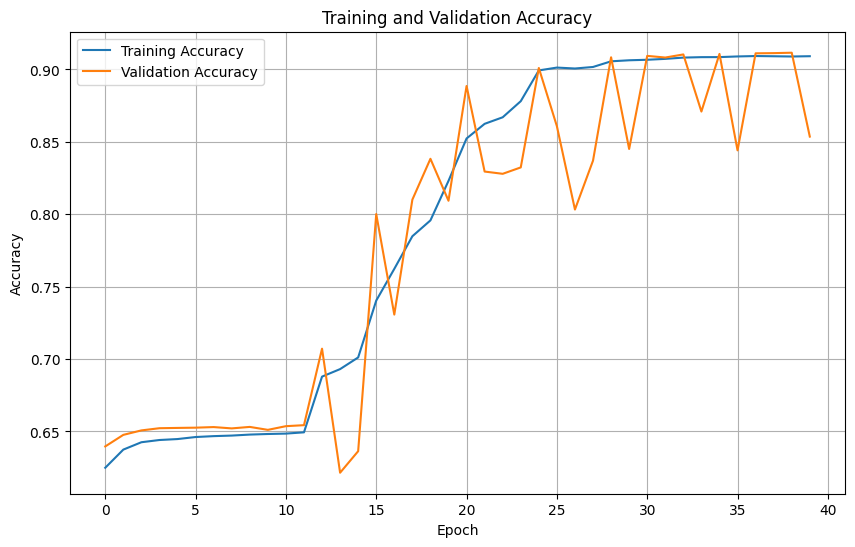

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

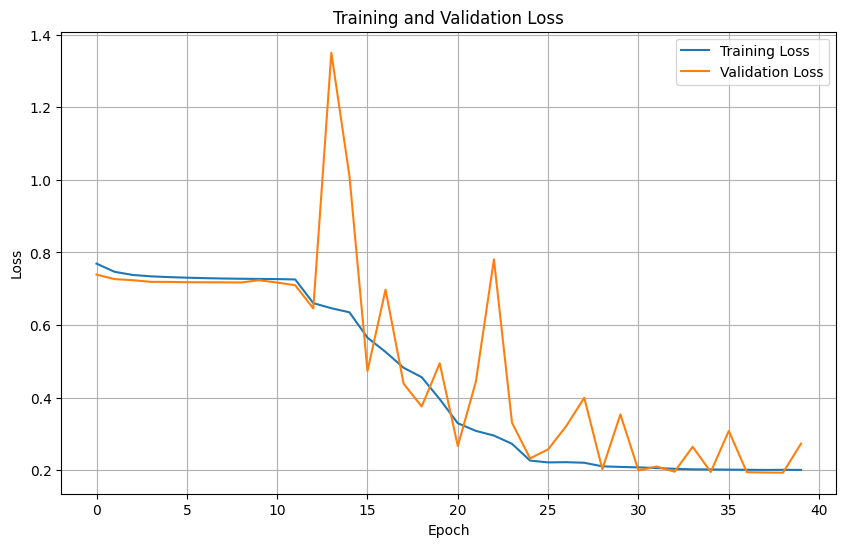

In [24]:
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

15133/15133 ━━━━━━━━━━━━━━━━━━━━ 91s 6ms/step


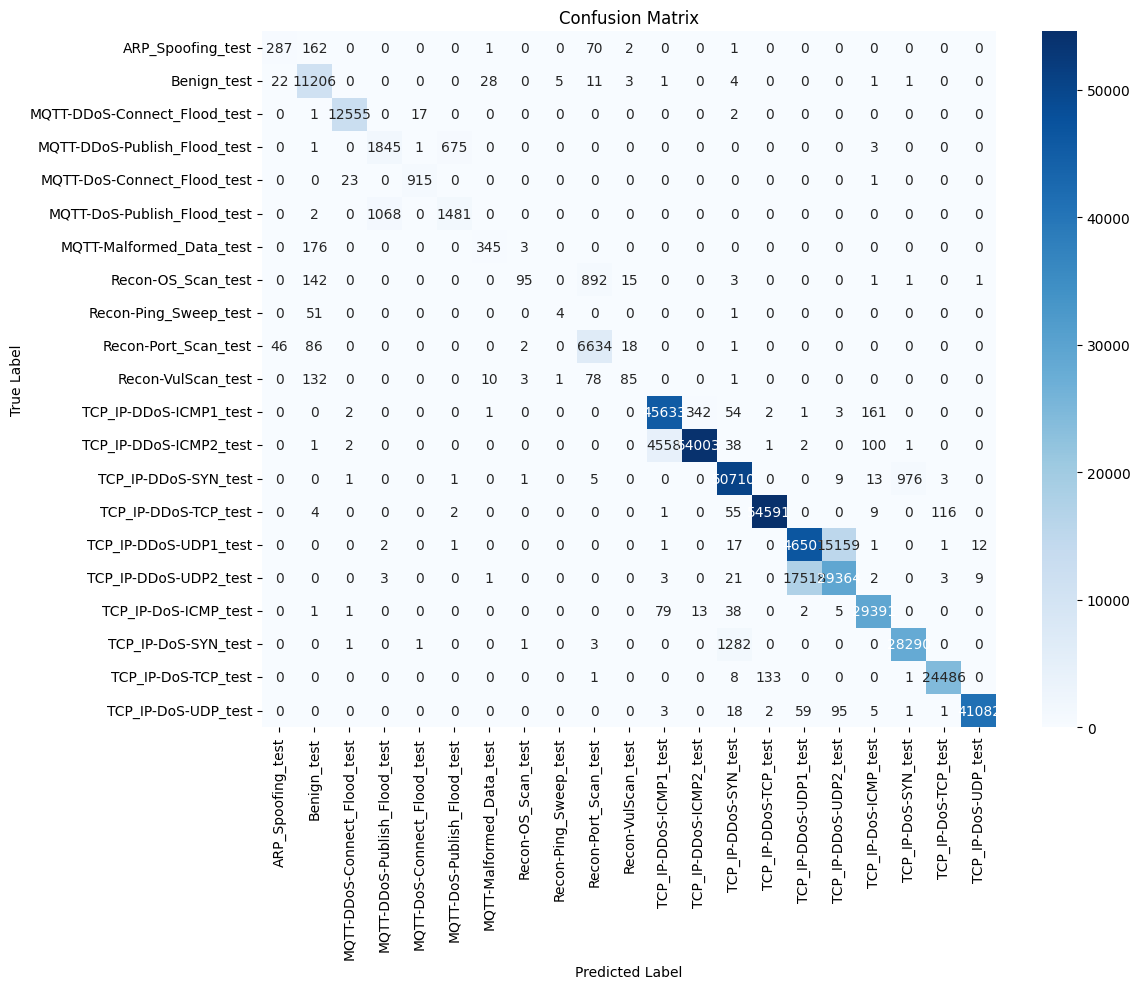

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predict classes for test data
y_pred = model.predict(X_test_seq)
y_pred_classes = y_pred.argmax(axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_test_seq, y_pred_classes)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_enc.classes_,
            yticklabels=label_enc.classes_,
            ax=ax)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
coinbase = w3.eth.accounts[0]
print(f"Coinbase: {coinbase}")
print(f"Coinbase balance: {w3.from_wei(w3.eth.get_balance(coinbase), 'ether')} ETH")

fund_tx = w3.eth.send_transaction({
    'from':  coinbase,
    'to':    account,
    'value': w3.to_wei(0.5, 'ether'),   # ← reduced from 10 to 0.5 ETH
})
receipt = w3.eth.wait_for_transaction_receipt(fund_tx)
print(f"✅ Funded! New balance: {w3.from_wei(w3.eth.get_balance(account), 'ether')} ETH")


Coinbase: 0x03DF376cD39dd1706A903126dBC382846DB16929
Coinbase balance: 1.07355341897344 ETH
✅ Funded! New balance: 0.5 ETH


In [ ]:
stuck_nonce = w3.eth.get_transaction_count(account, 'pending') - 1
print(f"Stuck nonce: {stuck_nonce}")

cancel_tx = {
    'from':     account,
    'to':       account,
    'value':    0,
    'gas':      21000,
    'gasPrice': 100,
    'nonce':    stuck_nonce,
    'chainId':  w3.eth.chain_id,
}
signed_cancel = w3.eth.account.sign_transaction(cancel_tx, private_key)
cancel_hash   = w3.eth.send_raw_transaction(signed_cancel.raw_transaction)
w3.eth.wait_for_transaction_receipt(cancel_hash)
print(f"✅ Stuck nonce cleared: {w3.to_hex(cancel_hash)}")


In [ ]:
import lightgbm as lgb
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from web3 import Web3
from web3.middleware import ExtraDataToPOAMiddleware
import time
import os
import json
import pandas as pd
import numpy as np

# ── 1. Load dataset ───────────────────────────────────────────────────────────
data_path = r"D:\Intensive Period\Review_IEEE_IoT\CIC_IoMT_2024_WiFi_MQTT_test.csv"
df = pd.read_csv(data_path)

df['Source_IP']      = df['Source_IP'].astype(str)
df['Destination_IP'] = df['Destination_IP'].astype(str)

# ── 2. Severity scores ────────────────────────────────────────────────────────
severity_scores = {
    'TCP_IP-DDoS-ICMP1_test':         10,
    'TCP_IP-DDoS-ICMP2_test':         10,
    'MQTT-DDoS-Connect_Flood_test':    9,
    'MQTT-DDoS-Publish_Flood_test':    9,
    'TCP_IP-DDoS-TCP_test':            9,
    'TCP_IP-DDoS-SYN_test':            9,
    'TCP_IP-DDoS-UDP1_test':           9,
    'TCP_IP-DDoS-UDP2_test':           9,
    'MQTT-DoS-Connect_Flood_test':     8,
    'MQTT-DoS-Publish_Flood_test':     8,
    'ARP_Spoofing_test':               7,
    'TCP_IP-DoS-ICMP_test':            7,
    'TCP_IP-DoS-SYN_test':             7,
    'TCP_IP-DoS-UDP_test':             7,
    'TCP_IP-DoS-TCP_test':             7,
    'Recon-VulScan_test':              6,
    'MQTT-Malformed_Data_test':        6,
    'Recon-OS_Scan_test':              5,
    'Recon-Port_Scan_test':            5,
    'Recon-OS_Sweep_test':             4,
    'Benign_test':                     0,
}

df['Severity_Score'] = df['label'].map(severity_scores).fillna(1).astype(int)

# ── 3. Feature / label split ──────────────────────────────────────────────────
drop_cols    = ['label', 'Severity_Score', 'Source_IP', 'Destination_IP']
feature_cols = [c for c in df.columns if c not in drop_cols]

X     = df[feature_cols].values
y_raw = df['label'].values

label_enc = LabelEncoder()
y_enc     = label_enc.fit_transform(y_raw)

# ── 4. Train / val / test split ───────────────────────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_enc, test_size=0.3, random_state=42, stratify=y_enc
)
X_val, X_test, y_val, y_test_enc = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# ── 5. Scale features ─────────────────────────────────────────────────────────
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# ── 6. LightGBM Datasets ──────────────────────────────────────────────────────
train_data = lgb.Dataset(X_train_scaled, label=y_train)
valid_data = lgb.Dataset(X_val_scaled,   label=y_val, reference=train_data)

# ── 7. Train & measure time ───────────────────────────────────────────────────
num_classes = len(label_enc.classes_)

params = {
    'objective':     'multiclass',
    'num_class':     num_classes,
    'metric':        'multi_logloss',
    'learning_rate': 0.05,
    'num_leaves':    31,
    'verbose':       -1
}

t0 = time.perf_counter()
bst = lgb.train(
    params,
    train_data,
    valid_sets=[valid_data],
    num_boost_round=100,
    callbacks=[lgb.early_stopping(stopping_rounds=10)]
)
training_time = time.perf_counter() - t0
print(f"Training Time: {training_time:.4f} seconds")

# ── 8. FIXED: Correct batch inference timing (matches XGB/RF method) ──────────
t0 = time.perf_counter()
y_pred_prob = bst.predict(X_test_scaled)
infer_time  = time.perf_counter() - t0

y_pred = y_pred_prob.argmax(axis=1)

n_test_samples = X_test_scaled.shape[0]
infer_time_per_sample_ms = (infer_time / n_test_samples) * 1000

print(f"Total Inference Time          : {infer_time:.4f} s  (on {n_test_samples} samples)")
print(f"Inference Time (per sample)   : {infer_time_per_sample_ms:.6f} ms")

# ── 9. Model size ─────────────────────────────────────────────────────────────
model_file = "lightgbm_model.txt"
bst.save_model(model_file)
model_size = os.path.getsize(model_file) / (1024 * 1024)
print(f"Model Size: {model_size:.4f} MB")

# ── 10. FLOPs estimate ────────────────────────────────────────────────────────
num_trees    = bst.num_trees()
approx_flops = num_trees * params['num_leaves'] * 2
print(f"Approximate FLOPs: {approx_flops} operations")

# ── 11. Classification report ─────────────────────────────────────────────────
print("\nLightGBM Classification Report:")
print(classification_report(y_test_enc, y_pred, target_names=label_enc.classes_))

# ── 13. Blockchain connection (PoA fix) ───────────────────────────────────────
w3 = Web3(Web3.HTTPProvider('https://purechainnode.com:8547'))
w3.middleware_onion.inject(ExtraDataToPOAMiddleware, layer=0)  # ← PoA fix

print(f"Blockchain Connected: {w3.is_connected()}")
print(f"Chain ID: {w3.eth.chain_id}")

contract_address = '0xC7f20054e3E29f781D5c318Db1bbaa981288dF25'
contract_abi = json.loads('''[
    {
        "inputs": [
            {
                "internalType": "uint256",
                "name": "_severityThreshold",
                "type": "uint256"
            }
        ],
        "stateMutability": "nonpayable",
        "type": "constructor"
    },
    {
        "anonymous": false,
        "inputs": [
            {
                "indexed": false,
                "internalType": "uint256",
                "name": "threatId",
                "type": "uint256"
            },
            {
                "indexed": false,
                "internalType": "string",
                "name": "threatType",
                "type": "string"
            },
            {
                "indexed": false,
                "internalType": "uint256",
                "name": "severity",
                "type": "uint256"
            }
        ],
        "name": "AlertLogged",
        "type": "event"
    },
    {
        "anonymous": false,
        "inputs": [
            {
                "indexed": true,
                "internalType": "bytes32",
                "name": "entity",
                "type": "bytes32"
            }
        ],
        "name": "Blocked",
        "type": "event"
    },
    {
        "inputs": [
            {
                "internalType": "uint256",
                "name": "threatId",
                "type": "uint256"
            },
            {
                "internalType": "string",
                "name": "threatType",
                "type": "string"
            },
            {
                "internalType": "uint256",
                "name": "severity",
                "type": "uint256"
            },
            {
                "internalType": "bytes32",
                "name": "entityHash",
                "type": "bytes32"
            }
        ],
        "name": "logAlert",
        "outputs": [],
        "stateMutability": "nonpayable",
        "type": "function"
    },
    {
        "anonymous": false,
        "inputs": [
            {
                "indexed": false,
                "internalType": "uint256",
                "name": "threatId",
                "type": "uint256"
            },
            {
                "indexed": false,
                "internalType": "string",
                "name": "action",
                "type": "string"
            },
            {
                "indexed": false,
                "internalType": "bytes32",
                "name": "entityHash",
                "type": "bytes32"
            }
        ],
        "name": "ResponseTriggered",
        "type": "event"
    },
    {
        "anonymous": false,
        "inputs": [
            {
                "indexed": true,
                "internalType": "bytes32",
                "name": "entity",
                "type": "bytes32"
            }
        ],
        "name": "Unblocked",
        "type": "event"
    },
    {
        "inputs": [
            {
                "internalType": "bytes32",
                "name": "entityHash",
                "type": "bytes32"
            }
        ],
        "name": "unblockEntity",
        "outputs": [],
        "stateMutability": "nonpayable",
        "type": "function"
    },
    {
        "inputs": [
            {
                "internalType": "uint256",
                "name": "newThreshold",
                "type": "uint256"
            }
        ],
        "name": "updateSeverityThreshold",
        "outputs": [],
        "stateMutability": "nonpayable",
        "type": "function"
    },
    {
        "inputs": [
            {
                "internalType": "bytes32",
                "name": "",
                "type": "bytes32"
            }
        ],
        "name": "blockedEntities",
        "outputs": [
            {
                "internalType": "bool",
                "name": "",
                "type": "bool"
            }
        ],
        "stateMutability": "view",
        "type": "function"
    },
    {
        "inputs": [
            {
                "internalType": "bytes32",
                "name": "entityHash",
                "type": "bytes32"
            }
        ],
        "name": "isBlocked",
        "outputs": [
            {
                "internalType": "bool",
                "name": "",
                "type": "bool"
            }
        ],
        "stateMutability": "view",
        "type": "function"
    },
    {
        "inputs": [],
        "name": "owner",
        "outputs": [
            {
                "internalType": "address",
                "name": "",
                "type": "address"
            }
        ],
        "stateMutability": "view",
        "type": "function"
    },
    {
        "inputs": [],
        "name": "severityThreshold",
        "outputs": [
            {
                "internalType": "uint256",
                "name": "",
                "type": "uint256"
            }
        ],
        "stateMutability": "view",
        "type": "function"
    }
]''')

contract    = w3.eth.contract(address=contract_address, abi=contract_abi)
private_key = '# ← your real key'
account     = '0x30e0Fe535DEDdB072743B847eDC48bD5EC54AD02'

# ── 14. Rebuild test-split indices aligned to df ──────────────────────────────
# Re-derive original df indices that correspond to the test split
all_indices           = np.arange(len(df))
train_val_idx, test_idx = train_test_split(
    all_indices, test_size=0.3, random_state=42, stratify=y_enc
)
val_idx, test_idx_final = train_test_split(
    test_idx, test_size=0.5, random_state=42, stratify=y_enc[test_idx]
)

# ── 15. Send transactions to blockchain ───────────────────────────────────────
# Nonce is already clean — start from 'latest' confirmed nonce
base_nonce = w3.eth.get_transaction_count(account, 'latest')
print(f"Starting nonce: {base_nonce}")

for i, idx in enumerate(test_idx_final):
    threat_type         = df['label'].iloc[idx]
    severity_score      = int(df['Severity_Score'].iloc[idx])
    entity_ip           = df['Source_IP'].iloc[idx]
    entity_hash         = Web3.keccak(text=entity_ip).hex()
    entity_hash_bytes32 = bytes.fromhex(entity_hash[2:]).rjust(32, b'\0')

    tx = contract.functions.logAlert(
        i,
        threat_type,
        severity_score,
        entity_hash_bytes32
    ).build_transaction({
        'chainId':  w3.eth.chain_id,
        'gas':      2000000,
        'gasPrice': 10,
        'nonce':    base_nonce + i,       # ← increments cleanly from 2444
        'from':     account,
    })

    signed_tx = w3.eth.account.sign_transaction(tx, private_key)
    tx_hash   = w3.eth.send_raw_transaction(signed_tx.raw_transaction)
    print(f"[{i}] Threat: {threat_type} | Severity: {severity_score} | Entity Hash: {entity_hash} | TX: {w3.to_hex(tx_hash)}")





In [ ]:
# ── Add these at the top of your test cell ───────────────────────────────────
private_key = '# ← your real key'
account     = '0x30e0Fe535DEDdB072743B847eDC48bD5EC54AD02'

# ── Then send test transactions ───────────────────────────────────────────────
test_nonce = w3.eth.get_transaction_count(account, 'latest')

test_cases = [
    ("TCP_IP-DDoS-SYN_test",  9,  "10.0.0.1"),
    ("Benign_test",            0,  "10.0.0.2"),
    ("TCP_IP-DoS-ICMP_test",   7,  "10.0.0.3"),
    ("Recon-OS_Scan_test",     5,  "10.0.0.4"),
]

for i, (threat_type, severity, ip) in enumerate(test_cases):
    entity_hash         = Web3.keccak(text=ip).hex()
    entity_hash_bytes32 = bytes.fromhex(entity_hash[2:]).rjust(32, b'\0')

    tx = contract.functions.logAlert(
        99999 + i,
        threat_type,
        severity,
        entity_hash_bytes32
    ).build_transaction({
        'chainId':  w3.eth.chain_id,
        'gas':      2000000,
        'gasPrice': 10,
        'nonce':    test_nonce + i,
        'from':     account,
    })

    signed_tx = w3.eth.account.sign_transaction(tx, private_key)
    tx_hash   = w3.eth.send_raw_transaction(signed_tx.raw_transaction)
    print(f"Sent: {threat_type} | Severity: {severity} | TX: {w3.to_hex(tx_hash)}")


In [ ]:
import matplotlib.pyplot as plt

# Define feature columns (exclude target columns)
feature_cols = [col for col in full_df.columns if col not in ['label', 'label_encoded']]

# Get feature importance scores
importance = bst.feature_importance(importance_type='gain')
sorted_idx = importance.argsort()[-20:][::-1]  # Top 20 features

plt.figure(figsize=(10,6))
plt.barh(range(20), importance[sorted_idx], align='center')
plt.yticks(range(20), [feature_cols[i] for i in sorted_idx])
plt.xlabel('Feature Importance (Gain)')
plt.title('Top 20 Important Features for Intrusion Detection')
plt.gca().invert_yaxis()
plt.show()

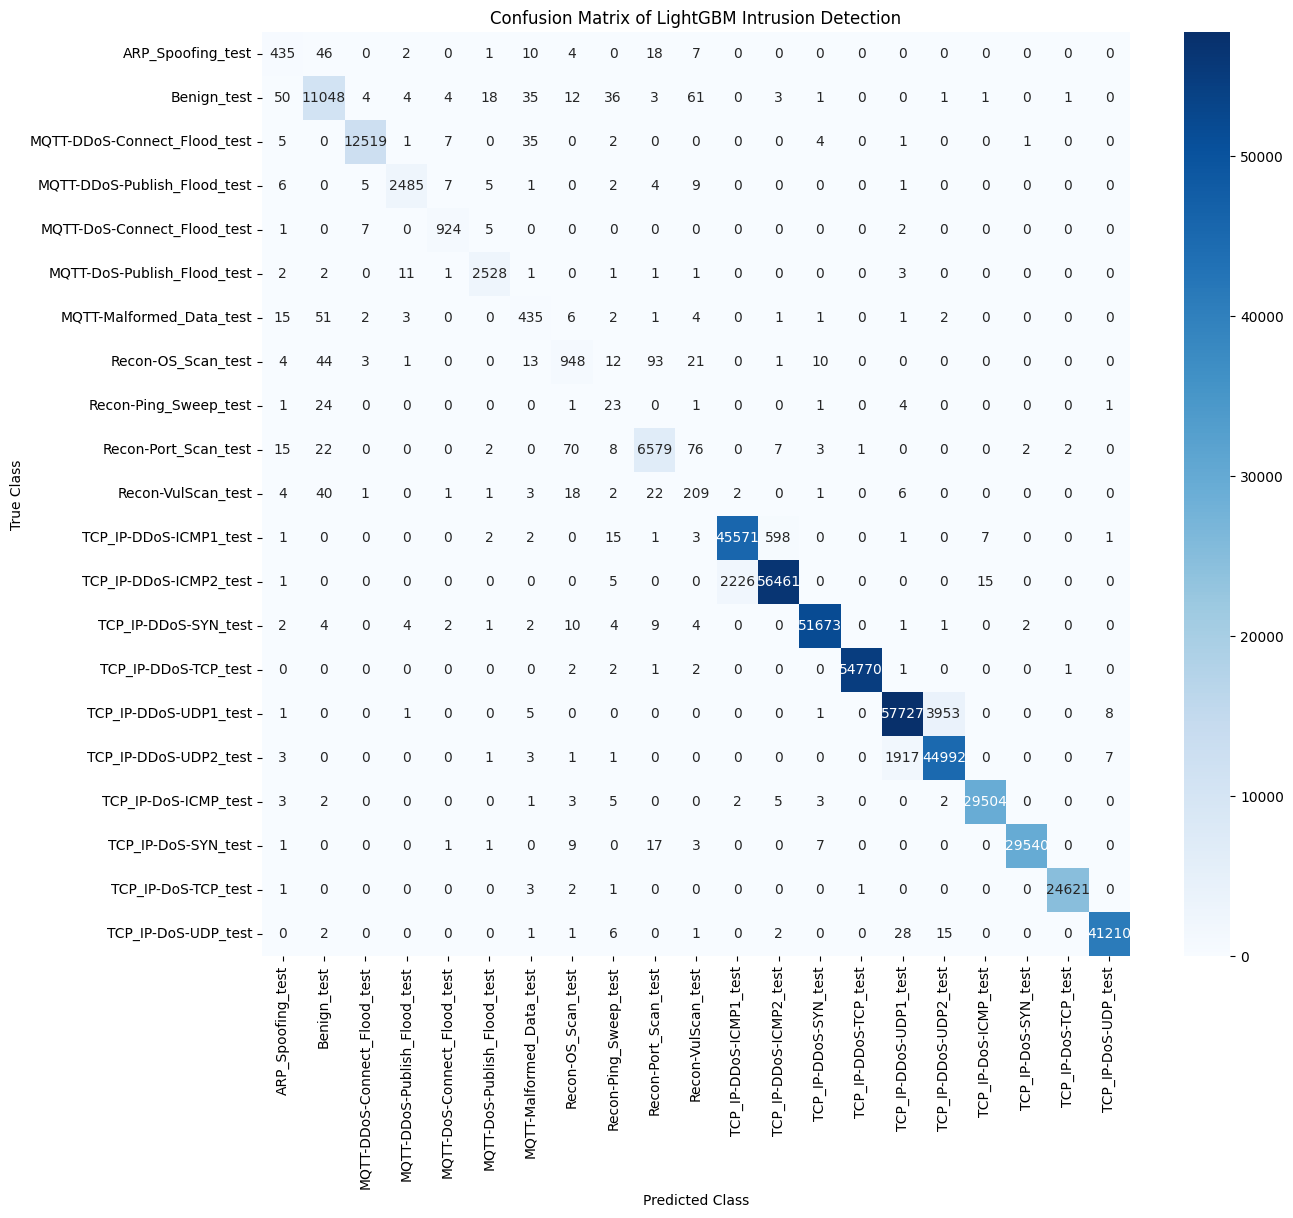

Classification Report:
                               precision    recall  f1-score   support

           ARP_Spoofing_test       0.79      0.83      0.81       523
                 Benign_test       0.98      0.98      0.98     11282
MQTT-DDoS-Connect_Flood_test       1.00      1.00      1.00     12575
MQTT-DDoS-Publish_Flood_test       0.99      0.98      0.99      2525
 MQTT-DoS-Connect_Flood_test       0.98      0.98      0.98       939
 MQTT-DoS-Publish_Flood_test       0.99      0.99      0.99      2551
    MQTT-Malformed_Data_test       0.79      0.83      0.81       524
          Recon-OS_Scan_test       0.87      0.82      0.85      1150
       Recon-Ping_Sweep_test       0.18      0.41      0.25        56
        Recon-Port_Scan_test       0.97      0.97      0.97      6787
          Recon-VulScan_test       0.52      0.67      0.59       310
      TCP_IP-DDoS-ICMP1_test       0.95      0.99      0.97     46202
      TCP_IP-DDoS-ICMP2_test       0.99      0.96      0.98     5

In [35]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Predict classes on test data
y_pred = bst.predict(X_test_scaled).argmax(axis=1)

# Confusion matrix
cm = confusion_matrix(y_test_enc, y_pred)

plt.figure(figsize=(14,12))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_enc.classes_, yticklabels=label_enc.classes_, cmap='Blues')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix of LightGBM Intrusion Detection')
plt.show()

# Detailed classification report
report = classification_report(y_test_enc, y_pred, target_names=label_enc.classes_)
print("Classification Report:\n", report)

In [40]:
import os
os.chdir(r'D:\Intensive Period\Review_IEEE_IoT\tf_notebook')
files = [f for f in os.listdir('.') if any(f.endswith(ext) for ext in ['.keras', '.pkl', '.txt', '.h5'])]
print(files)


['label_enc.pkl', 'lightgbm_model.txt', 'lstm_model.keras', 'lstm_pred_prob.pkl', 'train_valid_data.pkl', 'X_test_scaled.pkl', 'X_train_scaled.pkl', 'y_test_seq.pkl', 'y_train_enc.pkl']


In [41]:
import pickle
import numpy as np

# Save model
model.save('lstm_model.keras')
print("✅ LSTM model saved")

# Save LSTM predictions
lstm_pred_prob = model.predict(X_test_seq)
with open('lstm_pred_prob.pkl', 'wb') as f: pickle.dump(lstm_pred_prob, f)
with open('y_test_seq.pkl',     'wb') as f: pickle.dump(y_test_seq, f)
with open('label_enc.pkl',      'wb') as f: pickle.dump(label_enc, f)

# Save raw arrays for LGBM
with open('X_train_scaled.pkl', 'wb') as f: pickle.dump(X_train_scaled, f)
with open('y_train_enc.pkl',    'wb') as f: pickle.dump(y_train_enc, f)
with open('X_test_scaled.pkl',  'wb') as f: pickle.dump(X_test_scaled, f)  # ← FIXED 'wb'

print("✅ All saved!")


✅ LSTM model saved
15133/15133 ━━━━━━━━━━━━━━━━━━━━ 91s 6ms/step
✅ All saved!


In [42]:
import time
import os
import lightgbm as lgb
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support

# ── STEP 1: LSTM inference ────────────────────────────────────────────────────
print("Generating LSTM predictions...")
_ = model.predict(X_test_seq[:100], verbose=0)          # warmup

t0 = time.perf_counter()
lstm_pred_prob = model.predict(X_test_seq, verbose=0, batch_size=32)
lstm_inf_total_s = time.perf_counter() - t0

lstm_train_s          = 40 * 465
lstm_size_mb          = 15.0923
lstm_flops_per_sample = 2.63e7
seq_length            = 10

print(f"LSTM inference done: {lstm_inf_total_s:.4f} s for {len(X_test_seq)} samples")
print(f"LSTM per-sample    : {(lstm_inf_total_s / len(X_test_seq)) * 1000:.6f} ms")

# ── STEP 2: LightGBM train + inference ───────────────────────────────────────
params = {
    'objective':     'multiclass',
    'num_class':     len(label_enc.classes_),
    'metric':        'multi_logloss',
    'learning_rate': 0.05,
    'num_leaves':    31,
    'verbose':       -1
}

t0 = time.perf_counter()
bst = lgb.train(
    params, train_data,
    valid_sets=[valid_data],
    num_boost_round=100,
    callbacks=[lgb.early_stopping(10)]
)
lgbm_train_s = time.perf_counter() - t0
print(f"LGBM Training Time: {lgbm_train_s:.4f} s")

# LGBM inference (batch method, consistent with XGB/RF)
_ = bst.predict(X_test_scaled[:100])                    # warmup

t0 = time.perf_counter()
lgb_pred_prob = bst.predict(X_test_scaled)
lgbm_inf_total_s = time.perf_counter() - t0
lgbm_inf_per_sample_ms = (lgbm_inf_total_s / len(X_test_scaled)) * 1000

# LGBM model size
model_file = "lightgbm_model.txt"
bst.save_model(model_file)
lgbm_size_mb = os.path.getsize(model_file) / (1024**2)

# LGBM FLOPs (tree traversal)
model_json = bst.dump_model()
depths = []

def traverse(node, depth):
    if 'left_child' not in node and 'right_child' not in node:
        depths.append(depth); return
    if 'left_child'  in node: traverse(node['left_child'],  depth + 1)
    if 'right_child' in node: traverse(node['right_child'], depth + 1)

for tree in model_json['tree_info']:
    traverse(tree['tree_structure'], 1)

avg_depth             = sum(depths) / len(depths) if depths else 0
n_trees               = len(model_json['tree_info'])
lgbm_flops_per_sample = 2 * n_trees * avg_depth
print(f"LGBM Size: {lgbm_size_mb:.4f} MB | FLOPs/sample: {lgbm_flops_per_sample:.2e}")

# ── STEP 3: Hybrid ensemble ───────────────────────────────────────────────────
lgb_pred_prob_aligned = lgb_pred_prob[seq_length - 1:]  # align (484246, 21)
y_test_seq_aligned    = y_test_seq

ensemble_prob = (0.5 * lgb_pred_prob_aligned) + (0.5 * lstm_pred_prob)
ensemble_pred = ensemble_prob.argmax(axis=1)

# ── STEP 4: Evaluation ───────────────────────────────────────────────────────
print("\n=== Hybrid Classification Report ===")
print(classification_report(y_test_seq_aligned, ensemble_pred,
                             target_names=label_enc.classes_))

hybrid_acc = accuracy_score(y_test_seq_aligned, ensemble_pred)
prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(
    y_test_seq_aligned, ensemble_pred, average='macro',    zero_division=0)
prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
    y_test_seq_aligned, ensemble_pred, average='weighted', zero_division=0)

# Combined hybrid metrics
hybrid_train_s           = lstm_train_s + lgbm_train_s
hybrid_size_mb           = lstm_size_mb + lgbm_size_mb
hybrid_flops_per_sample  = lstm_flops_per_sample + lgbm_flops_per_sample
lstm_inf_per_sample_ms   = (lstm_inf_total_s / len(X_test_seq)) * 1000
hybrid_inf_per_sample_ms = lstm_inf_per_sample_ms + lgbm_inf_per_sample_ms

# ── FINAL TABLE ───────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("HYBRID MODEL — COPY TO LATEX TABLE")
print("="*60)
print(f"Accuracy          : {hybrid_acc * 100:.2f}%")
print(f"Precision (W)     : {prec_w * 100:.2f}%")
print(f"Recall    (W)     : {rec_w * 100:.2f}%")
print(f"F1-score  (W)     : {f1_w * 100:.2f}%")
print(f"Precision (M)     : {prec_m * 100:.2f}%")
print(f"Recall    (M)     : {rec_m * 100:.2f}%")
print(f"F1-score  (M)     : {f1_m * 100:.2f}%")
print(f"Train Time        : {hybrid_train_s:.1f} s")
print(f"Inf/Sample        : {hybrid_inf_per_sample_ms:.6f} ms")
print(f"Model Size        : {hybrid_size_mb:.4f} MB")
print(f"FLOPs/Sample      : {hybrid_flops_per_sample:.2e}")
print("="*60)


Generating LSTM predictions...
LSTM inference done: 90.9124 s for 484246 samples
LSTM per-sample    : 0.187740 ms
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[40]	valid_0's multi_logloss: 0.133549
LGBM Training Time: 11.5855 s
LGBM Size: 2.7932 MB | FLOPs/sample: 1.27e+04

=== Hybrid Classification Report ===
                              precision    recall  f1-score   support

           ARP_Spoofing_test       0.83      0.80      0.82       523
                 Benign_test       0.98      0.97      0.97     11282
MQTT-DDoS-Connect_Flood_test       1.00      1.00      1.00     12575
MQTT-DDoS-Publish_Flood_test       0.97      0.98      0.98      2525
 MQTT-DoS-Connect_Flood_test       0.94      0.99      0.96       939
 MQTT-DoS-Publish_Flood_test       0.97      0.98      0.98      2551
    MQTT-Malformed_Data_test       0.81      0.81      0.81       524
          Recon-OS_Scan_test       0.76      0.69      0.72      1150
      

In [43]:
from sklearn.metrics import classification_report

print("Ensemble Model Classification Report:")
print(classification_report(y_test_seq_aligned, ensemble_pred, target_names=label_enc.classes_))

Ensemble Model Classification Report:
                              precision    recall  f1-score   support

           ARP_Spoofing_test       0.83      0.80      0.82       523
                 Benign_test       0.98      0.97      0.97     11282
MQTT-DDoS-Connect_Flood_test       1.00      1.00      1.00     12575
MQTT-DDoS-Publish_Flood_test       0.97      0.98      0.98      2525
 MQTT-DoS-Connect_Flood_test       0.94      0.99      0.96       939
 MQTT-DoS-Publish_Flood_test       0.97      0.98      0.98      2551
    MQTT-Malformed_Data_test       0.81      0.81      0.81       524
          Recon-OS_Scan_test       0.76      0.69      0.72      1150
       Recon-Ping_Sweep_test       0.05      0.54      0.09        56
        Recon-Port_Scan_test       0.96      0.98      0.97      6787
          Recon-VulScan_test       0.64      0.68      0.66       310
      TCP_IP-DDoS-ICMP1_test       0.93      1.00      0.96     46199
      TCP_IP-DDoS-ICMP2_test       1.00      0.94  

Saved to: D:\Intensive Period\Review_IEEE_IoT\tf_notebook\confusion_matrix_hybrid.png


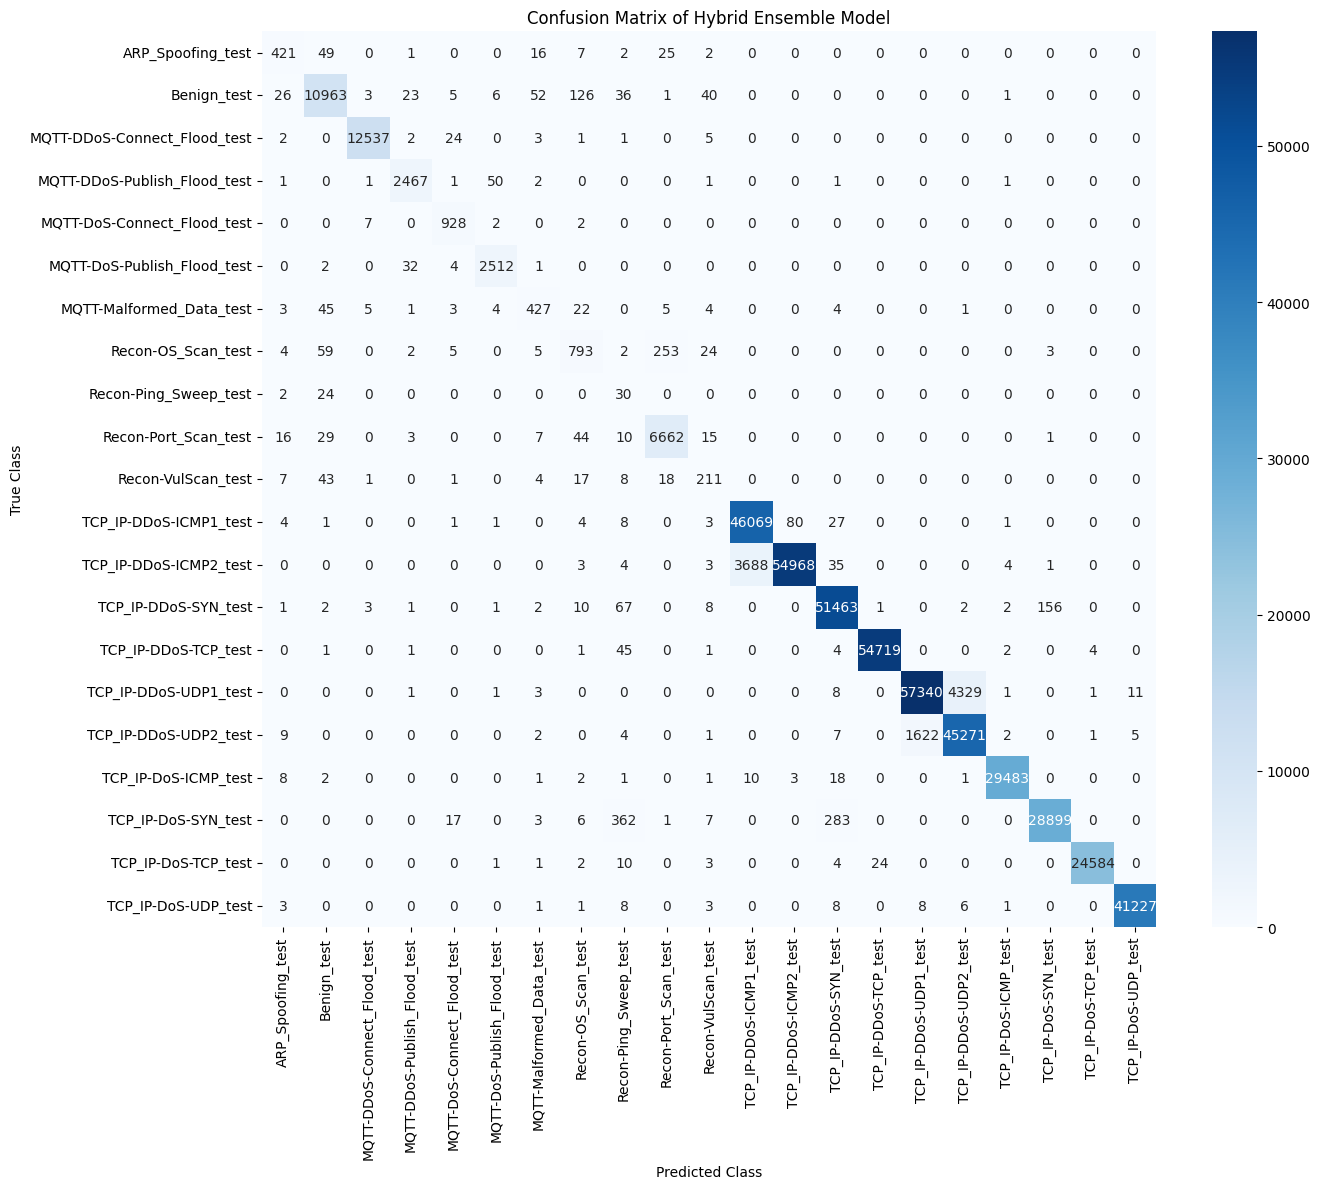

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os

cm = confusion_matrix(y_test_seq_aligned, ensemble_pred)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_enc.classes_,
            yticklabels=label_enc.classes_,
            ax=ax)
ax.set_xlabel('Predicted Class')
ax.set_ylabel('True Class')
ax.set_title('Confusion Matrix of Hybrid Ensemble Model')

plt.tight_layout()

save_path = os.path.join(os.getcwd(), 'confusion_matrix_hybrid.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved to: {save_path}")

plt.show()

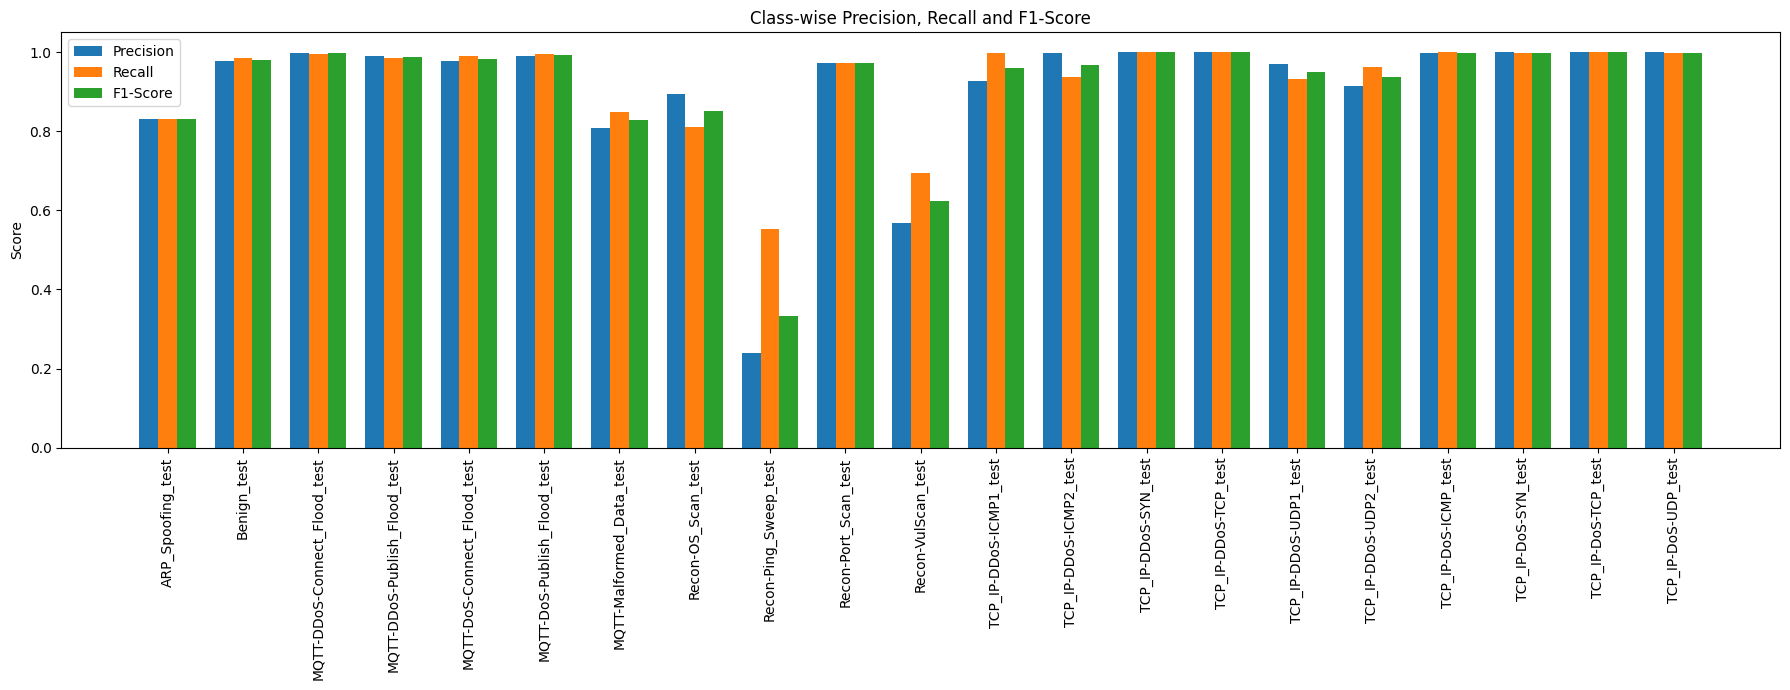

In [44]:
from sklearn.metrics import precision_recall_fscore_support
import numpy as np

precision, recall, f1_score, support = precision_recall_fscore_support(
    y_test_seq_aligned, ensemble_pred, zero_division=0
)

labels = label_enc.classes_

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(18,7))
plt.bar(x - width, precision, width, label='Precision')
plt.bar(x, recall, width, label='Recall')
plt.bar(x + width, f1_score, width, label='F1-Score')

plt.xticks(x, labels, rotation=90)
plt.ylabel('Score')
plt.title('Class-wise Precision, Recall and F1-Score')
plt.legend()
plt.tight_layout()
plt.show()

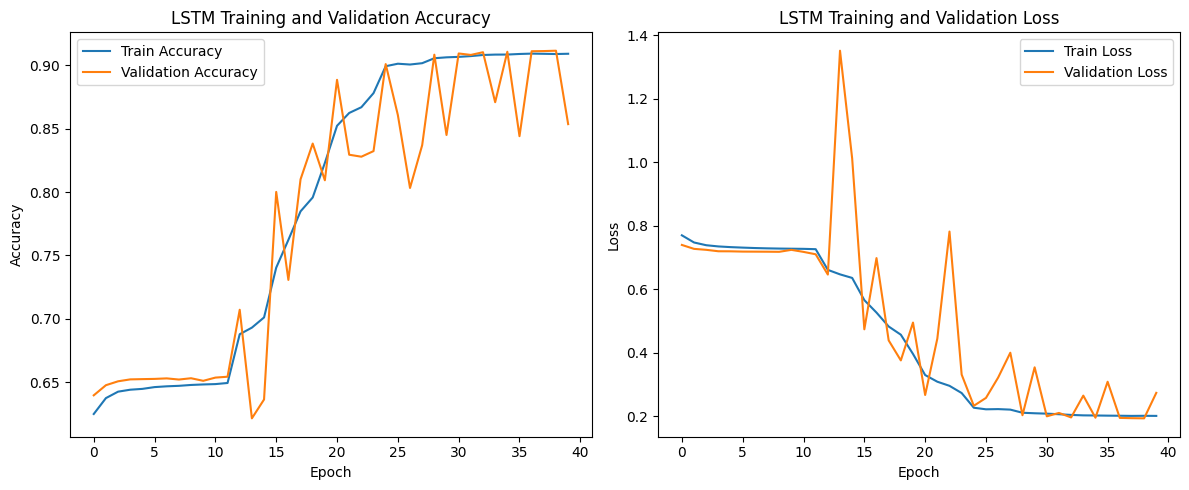

In [45]:
plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [27]:
!pip install requests

In [28]:
import requests

def send_alert_to_backend(threat_id, threat_type, severity, entity_id):
    url = "http://localhost:5000/update_alert"  # Change if your backend runs elsewhere
    alert_data = {
        "threat_id": threat_id,
        "threat_type": threat_type,
        "severity": severity,
        "entity_id": entity_id
    }
    try:
        response = requests.post(url, json=alert_data)
        print(f"Alert sent! Status code: {response.status_code}")
        print(f"Response: {response.json()}")
    except Exception as e:
        print(f"Failed to send alert: {e}")

In [29]:
# Example: replace with your actual detected values
send_alert_to_backend(101, "DDoS", 9, "203.0.113.45")

Alert sent! Status code: 200
Response: {'status': 'alert updated'}



Running seed=42
  Acc=97.9713%  P=98.0137%  R=97.9713%  F1=97.9791%

Running seed=0
  Acc=97.8714%  P=97.9171%  R=97.8714%  F1=97.8797%

Running seed=7
  Acc=97.9635%  P=98.0127%  R=97.9635%  F1=97.9748%

Running seed=123
  Acc=97.8264%  P=97.9203%  R=97.8264%  F1=97.8571%

Running seed=2024
  Acc=97.8284%  P=97.8720%  R=97.8284%  F1=97.8364%

95% CONFIDENCE INTERVALS (t-dist, df=4, n=5 seeds)
  accuracy    : 97.89% ± 0.09%  [97.80%, 97.98%]
  precision   : 97.95% ± 0.08%  [97.87%, 98.03%]
  recall      : 97.89% ± 0.09%  [97.80%, 97.98%]
  f1          : 97.91% ± 0.08%  [97.82%, 97.99%]

Per-seed results saved to lightgbm_ci_results.csv

LaTeX-ready values for Table VI:
  accuracy    : $97.9 \pm 0.09$
  precision   : $97.9 \pm 0.08$
  recall      : $97.9 \pm 0.09$
  f1          : $97.9 \pm 0.08$

Full Classification Report (seed=42 run):
                              precision    recall  f1-score   support

           ARP_Spoofing_test       0.77      0.79      0.78       261
         

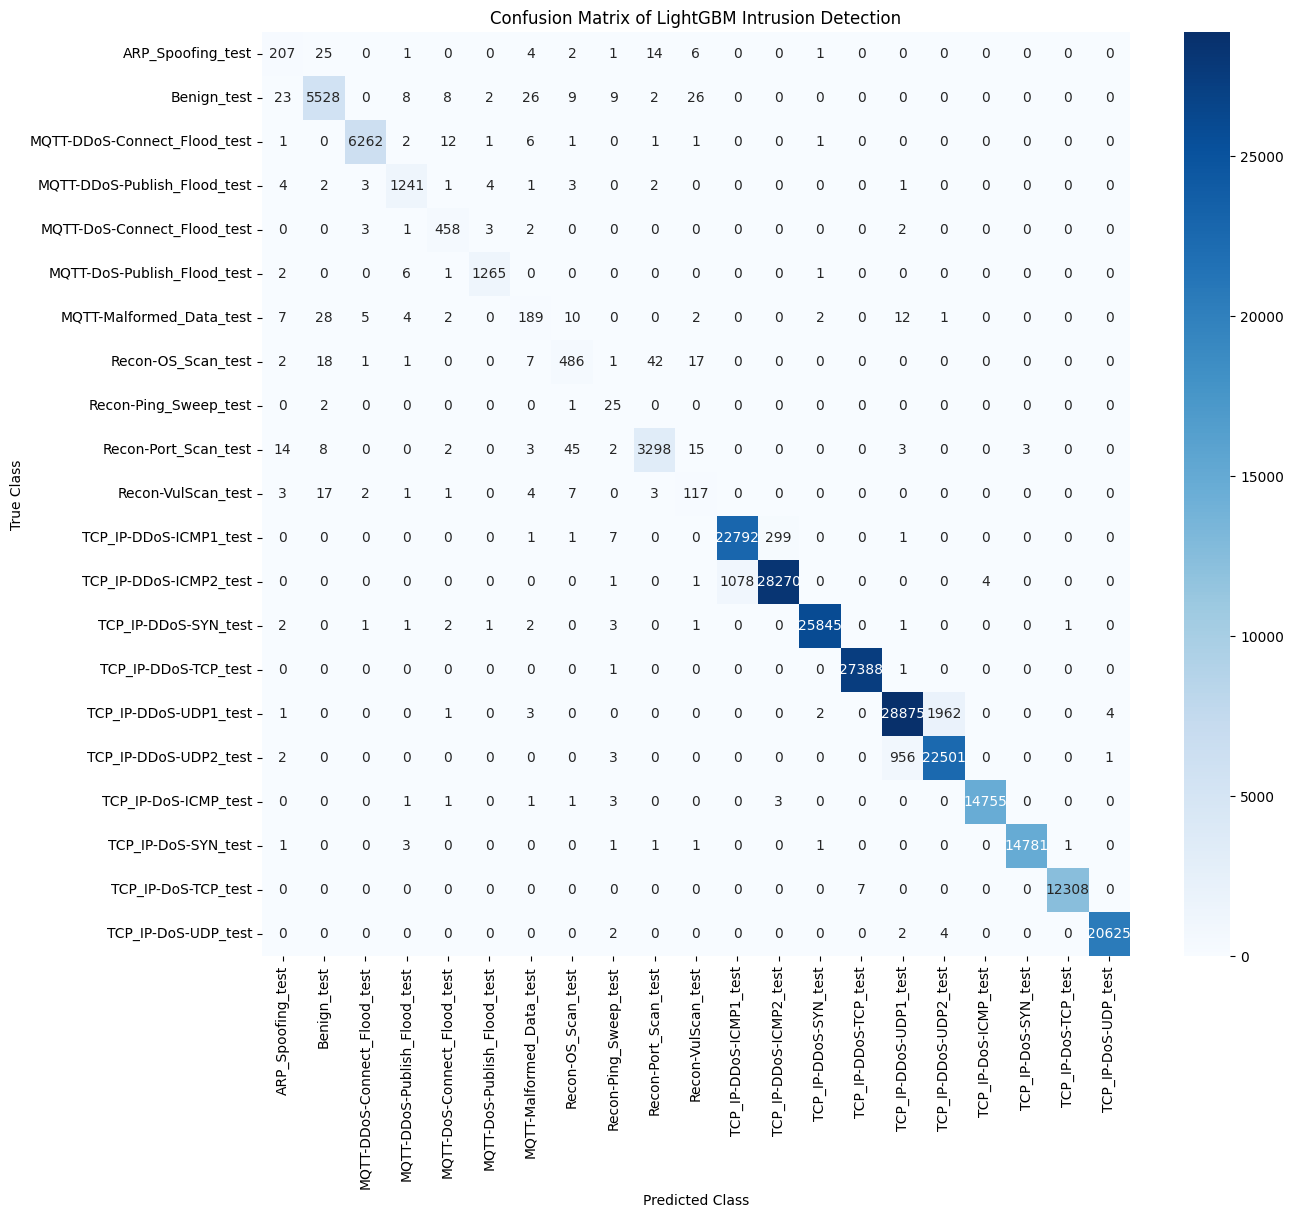

Classification Report:
                               precision    recall  f1-score   support

           ARP_Spoofing_test       0.77      0.79      0.78       261
                 Benign_test       0.98      0.98      0.98      5641
MQTT-DDoS-Connect_Flood_test       1.00      1.00      1.00      6288
MQTT-DDoS-Publish_Flood_test       0.98      0.98      0.98      1262
 MQTT-DoS-Connect_Flood_test       0.94      0.98      0.96       469
 MQTT-DoS-Publish_Flood_test       0.99      0.99      0.99      1275
    MQTT-Malformed_Data_test       0.76      0.72      0.74       262
          Recon-OS_Scan_test       0.86      0.85      0.85       575
       Recon-Ping_Sweep_test       0.42      0.89      0.57        28
        Recon-Port_Scan_test       0.98      0.97      0.98      3393
          Recon-VulScan_test       0.63      0.75      0.68       155
      TCP_IP-DDoS-ICMP1_test       0.95      0.99      0.97     23101
      TCP_IP-DDoS-ICMP2_test       0.99      0.96      0.98     2

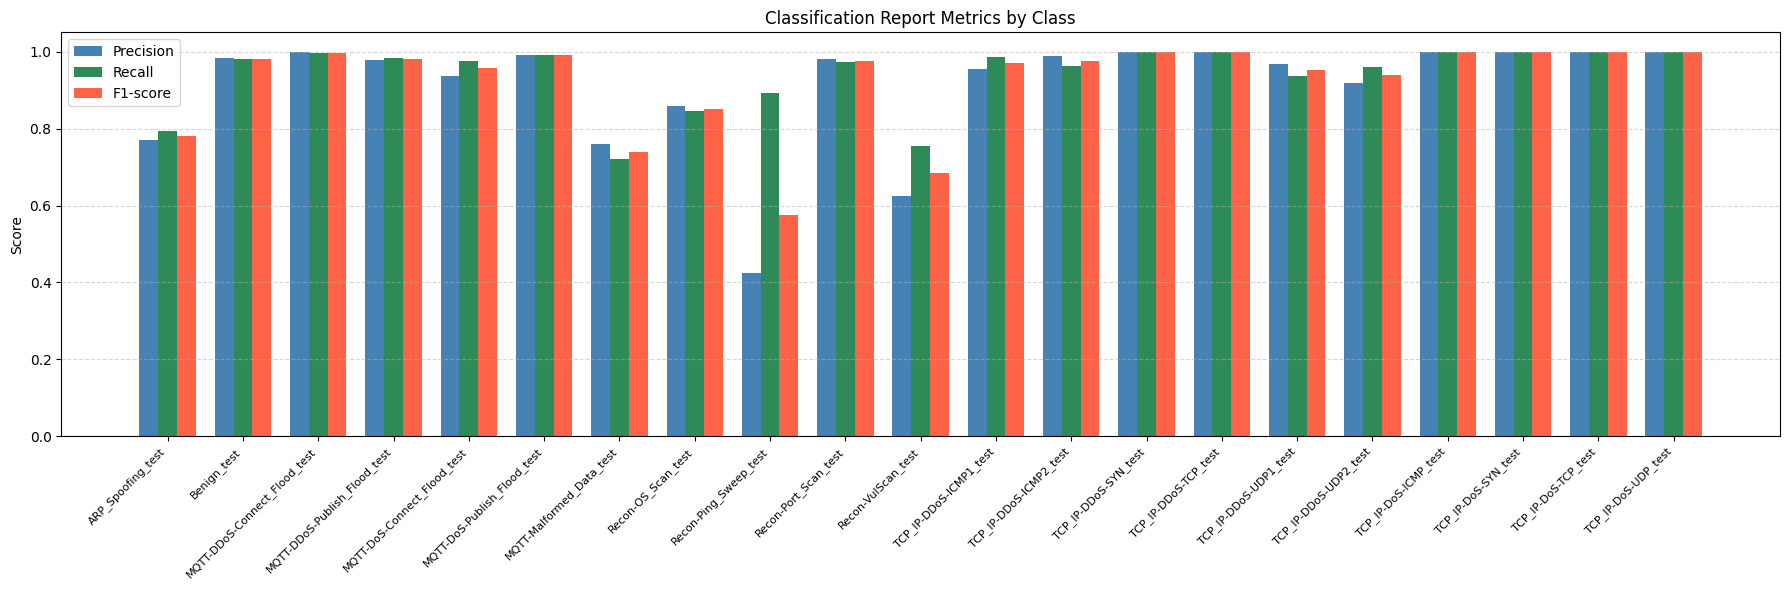

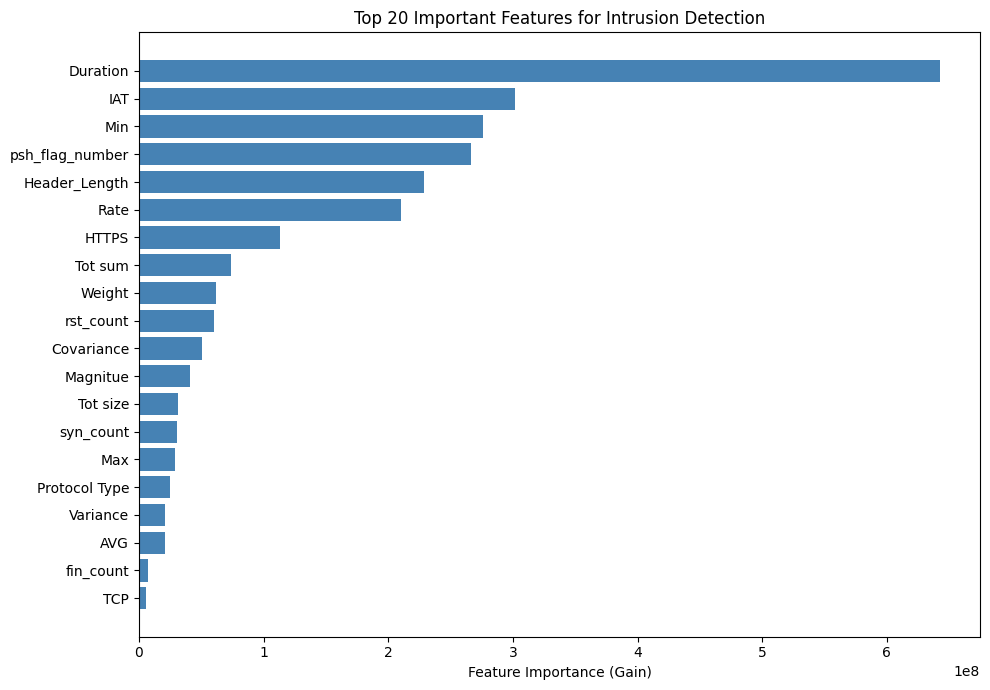

In [18]:
import lightgbm as lgb
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import time
import os
import json
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ── 1. Load dataset ───────────────────────────────────────────────────────────
data_path = r"D:\Intensive Period\Review_IEEE_IoT\CIC_IoMT_2024_WiFi_MQTT_test.csv"
df = pd.read_csv(data_path)

df['Source_IP']      = df['Source_IP'].astype(str)
df['Destination_IP'] = df['Destination_IP'].astype(str)

# ── 2. Severity scores ────────────────────────────────────────────────────────
severity_scores = {
    'TCP_IP-DDoS-ICMP1_test':         10,
    'TCP_IP-DDoS-ICMP2_test':         10,
    'MQTT-DDoS-Connect_Flood_test':    9,
    'MQTT-DDoS-Publish_Flood_test':    9,
    'TCP_IP-DDoS-TCP_test':            9,
    'TCP_IP-DDoS-SYN_test':            9,
    'TCP_IP-DDoS-UDP1_test':           9,
    'TCP_IP-DDoS-UDP2_test':           9,
    'MQTT-DoS-Connect_Flood_test':     8,
    'MQTT-DoS-Publish_Flood_test':     8,
    'ARP_Spoofing_test':               7,
    'TCP_IP-DoS-ICMP_test':            7,
    'TCP_IP-DoS-SYN_test':             7,
    'TCP_IP-DoS-UDP_test':             7,
    'TCP_IP-DoS-TCP_test':             7,
    'Recon-VulScan_test':              6,
    'MQTT-Malformed_Data_test':        6,
    'Recon-OS_Scan_test':              5,
    'Recon-Port_Scan_test':            5,
    'Recon-OS_Sweep_test':             4,
    'Benign_test':                     0,
}

df['Severity_Score'] = df['label'].map(severity_scores).fillna(1).astype(int)

# ── 3. Feature / label split ──────────────────────────────────────────────────
drop_cols    = ['label', 'Severity_Score', 'Source_IP', 'Destination_IP']
feature_cols = [c for c in df.columns if c not in drop_cols]

X     = df[feature_cols].values
y_raw = df['label'].values

label_enc = LabelEncoder()
y_enc     = label_enc.fit_transform(y_raw)

# ── 4. LightGBM params ───────────────────────────────────────────────────────
num_classes = len(label_enc.classes_)
params = {
    'objective':     'multiclass',
    'num_class':     num_classes,
    'metric':        'multi_logloss',
    'learning_rate': 0.05,
    'num_leaves':    31,
    'verbose':       -1
}

# ── 5. Multi-seed CI loop ─────────────────────────────────────────────────────
SEEDS = [42, 0, 7, 123, 2024]
records = []

for seed in SEEDS:
    print(f"\n{'='*50}\nRunning seed={seed}")

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y_enc, test_size=0.3, random_state=seed, stratify=y_enc
    )
    X_val, X_test, y_val, y_test_enc = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=seed, stratify=y_temp
    )

    scaler         = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled   = scaler.transform(X_val)
    X_test_scaled  = scaler.transform(X_test)

    train_data = lgb.Dataset(X_train_scaled, label=y_train)
    valid_data = lgb.Dataset(X_val_scaled,   label=y_val, reference=train_data)

    t0 = time.perf_counter()
    bst = lgb.train(
        params,
        train_data,
        valid_sets=[valid_data],
        num_boost_round=100,
        callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=False)]
    )
    train_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    y_pred_prob = bst.predict(X_test_scaled)
    infer_time  = time.perf_counter() - t0
    y_pred = y_pred_prob.argmax(axis=1)

    n = X_test_scaled.shape[0]
    infer_ms = (infer_time / n) * 1000

    acc  = accuracy_score(y_test_enc, y_pred) * 100
    prec = precision_score(y_test_enc, y_pred, average='weighted', zero_division=0) * 100
    rec  = recall_score(y_test_enc, y_pred, average='weighted', zero_division=0) * 100
    f1   = f1_score(y_test_enc, y_pred, average='weighted', zero_division=0) * 100

    records.append({
        'seed': seed,
        'accuracy': acc, 'precision': prec,
        'recall': rec, 'f1': f1,
        'train_time': train_time, 'infer_ms': infer_ms
    })
    print(f"  Acc={acc:.4f}%  P={prec:.4f}%  R={rec:.4f}%  F1={f1:.4f}%")

# ── 6. Compute 95% CI (t-distribution, n=5) ──────────────────────────────────
results_df = pd.DataFrame(records)
print("\n" + "="*60)
print("95% CONFIDENCE INTERVALS (t-dist, df=4, n=5 seeds)")
print("="*60)

ci_results = {}
for metric in ['accuracy', 'precision', 'recall', 'f1']:
    vals = results_df[metric].values
    mean = np.mean(vals)
    sem  = stats.sem(vals)
    ci   = stats.t.interval(0.95, df=len(vals)-1, loc=mean, scale=sem)
    half = ci[1] - mean
    ci_results[metric] = {'mean': mean, 'ci_half': half, 'ci_low': ci[0], 'ci_high': ci[1]}
    print(f"  {metric:12s}: {mean:.2f}% ± {half:.2f}%  [{ci[0]:.2f}%, {ci[1]:.2f}%]")

# ── 7. Save per-seed results ──────────────────────────────────────────────────
results_df.to_csv("lightgbm_ci_results.csv", index=False)
print("\nPer-seed results saved to lightgbm_ci_results.csv")

# ── 8. Print LaTeX-ready table cell values ────────────────────────────────────
print("\n" + "="*60)
print("LaTeX-ready values for Table VI:")
print("="*60)
for metric in ['accuracy', 'precision', 'recall', 'f1']:
    m = ci_results[metric]
    print(f"  {metric:12s}: ${m['mean']:.1f} \\pm {m['ci_half']:.2f}$")

# ── 9. Final single-run report (seed=42, for Table V classification report) ───
print("\n" + "="*60)
print("Full Classification Report (seed=42 run):")
print("="*60)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_enc, test_size=0.3, random_state=42, stratify=y_enc
)
X_val, X_test, y_val, y_test_enc = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)
train_data = lgb.Dataset(X_train_scaled, label=y_train)
valid_data = lgb.Dataset(X_val_scaled,   label=y_val, reference=train_data)
bst = lgb.train(params, train_data, valid_sets=[valid_data],
                num_boost_round=100,
                callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=False)])
y_pred = bst.predict(X_test_scaled).argmax(axis=1)
print(classification_report(y_test_enc, y_pred, target_names=label_enc.classes_))

# Save final model
model_file = "lightgbm_model.txt"
bst.save_model(model_file)
model_size = os.path.getsize(model_file) / (1024 * 1024)
num_trees  = bst.num_trees()
approx_flops = num_trees * params['num_leaves'] * 2
print(f"\nModel Size : {model_size:.4f} MB")
print(f"Approx FLOPs: {approx_flops}")

# ── Figure 1: Confusion Matrix (300 DPI) ─────────────────────────────────────
y_pred = bst.predict(X_test_scaled).argmax(axis=1)
cm = confusion_matrix(y_test_enc, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_enc.classes_,
            yticklabels=label_enc.classes_, cmap='Blues')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix of LightGBM Intrusion Detection')
plt.savefig('cm_lightgbm.png', dpi=300, bbox_inches='tight')
plt.show()

# Detailed classification report
report = classification_report(y_test_enc, y_pred, target_names=label_enc.classes_)
print("Classification Report:\n", report)

# ── Figure 2: Class-wise Precision, Recall, F1 (300 DPI) ─────────────────────
report_dict = classification_report(y_test_enc, y_pred,
                                    target_names=label_enc.classes_,
                                    output_dict=True, zero_division=0)
classes    = label_enc.classes_
precisions = [report_dict[c]['precision'] for c in classes]
recalls    = [report_dict[c]['recall']    for c in classes]
f1s        = [report_dict[c]['f1-score']  for c in classes]

x = np.arange(len(classes))
w = 0.25

fig, ax = plt.subplots(figsize=(18, 6))
ax.bar(x - w, precisions, w, label='Precision', color='steelblue')
ax.bar(x,     recalls,    w, label='Recall',    color='seagreen')
ax.bar(x + w, f1s,        w, label='F1-score',  color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Score')
ax.set_title('Classification Report Metrics by Class')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('per_class_lightgbm.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Figure 3: Top 20 Feature Importance by Gain (300 DPI) ────────────────────
importance = bst.feature_importance(importance_type='gain')
feat_df    = pd.DataFrame({'feature': feature_cols, 'gain': importance})
feat_df    = feat_df.nlargest(20, 'gain').sort_values('gain')

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(feat_df['feature'], feat_df['gain'], color='steelblue')
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('Top 20 Important Features for Intrusion Detection')
plt.tight_layout()
plt.savefig('feature_importance_lightgbm.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
import os
os.chdir(r'D:\Intensive Period\Review_IEEE_IoT\tf_notebook')
files = [f for f in os.listdir('.') if any(f.endswith(ext) for ext in ['.keras', '.pkl', '.txt', '.h5'])]
print(files)
import pickle
import numpy as np

# Save model
model.save('lstm_model.keras')
print("✅ LSTM model saved")

# Save LSTM predictions
lstm_pred_prob = model.predict(X_test_seq)
with open('lstm_pred_prob.pkl', 'wb') as f: pickle.dump(lstm_pred_prob, f)
with open('y_test_seq.pkl',     'wb') as f: pickle.dump(y_test_seq, f)
with open('label_enc.pkl',      'wb') as f: pickle.dump(label_enc, f)

# Save raw arrays for LGBM
with open('X_train_scaled.pkl', 'wb') as f: pickle.dump(X_train_scaled, f)
with open('y_train_enc.pkl',    'wb') as f: pickle.dump(y_train_enc, f)
with open('X_test_scaled.pkl',  'wb') as f: pickle.dump(X_test_scaled, f)

print("✅ All saved!")

import time
import os
import gc
import lightgbm as lgb
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.metrics import (classification_report, accuracy_score,
                             precision_recall_fscore_support,
                             precision_score, recall_score,
                             f1_score, confusion_matrix)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, BatchNormalization, Dropout, Dense
import tensorflow as tf

# ── CI loop ───────────────────────────────────────────────────────────────────
SEEDS = [42, 0, 7, 21, 99]
N_RUNS = 5

params = {
    'objective':     'multiclass',
    'num_class':     len(label_enc.classes_),
    'metric':        'multi_logloss',
    'learning_rate': 0.05,
    'num_leaves':    31,
    'verbose':       -1
}

run_accuracies  = []
run_f1s         = []
run_precisions  = []
run_recalls     = []

for seed in SEEDS:
    print(f"\n{'='*50}\nHybrid seed={seed}\n{'='*50}")
    tf.random.set_seed(seed)
    np.random.seed(seed)

    # ── Sequences (created fresh, deleted after) ──────────────────────────────
    X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_enc, seq_length)
    X_test_seq,  y_test_seq  = create_sequences(X_test_scaled,  y_test_enc,  seq_length)

    # ── LSTM ──────────────────────────────────────────────────────────────────
    num_classes = len(label_enc.classes_)

    lstm_model = Sequential([
        Bidirectional(LSTM(256, return_sequences=True), input_shape=(seq_length, X_train_scaled.shape[1])),
        BatchNormalization(),
        Dropout(0.3),
        Bidirectional(LSTM(128)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax')
    ])

    lstm_model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    earlystop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    reducelr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

    lstm_model.fit(X_train_seq, y_train_seq, epochs=40, batch_size=32,
                   validation_split=0.1, callbacks=[earlystop, reducelr])

    _ = lstm_model.predict(X_test_seq[:100], verbose=0)
    lstm_pred_prob_seed = lstm_model.predict(X_test_seq, verbose=0, batch_size=32)

    # ── LightGBM ──────────────────────────────────────────────────────────────
    train_data_seed = lgb.Dataset(X_train_scaled, label=y_train_enc)
    val_size        = int(len(X_train_scaled) * 0.1)
    valid_data_seed = lgb.Dataset(X_train_scaled[-val_size:],
                                  label=y_train_enc[-val_size:],
                                  reference=train_data_seed)

    bst_seed = lgb.train(
        params, train_data_seed,
        valid_sets=[valid_data_seed],
        num_boost_round=100,
        callbacks=[lgb.early_stopping(10, verbose=False)]
    )

    lgb_pred_prob_seed = bst_seed.predict(X_test_scaled)

    # ── Hybrid ensemble ───────────────────────────────────────────────────────
    lgb_pred_prob_aligned = lgb_pred_prob_seed[seq_length - 1:]
    y_test_seq_aligned    = y_test_seq

    ensemble_prob = (0.5 * lgb_pred_prob_aligned) + (0.5 * lstm_pred_prob_seed)
    ensemble_pred = ensemble_prob.argmax(axis=1)

    acc  = accuracy_score(y_test_seq_aligned, ensemble_pred) * 100
    prec = precision_score(y_test_seq_aligned, ensemble_pred, average='weighted', zero_division=0) * 100
    rec  = recall_score(y_test_seq_aligned,  ensemble_pred, average='weighted', zero_division=0) * 100
    f1   = f1_score(y_test_seq_aligned,      ensemble_pred, average='weighted', zero_division=0) * 100

    run_accuracies.append(acc)
    run_f1s.append(f1)
    run_precisions.append(prec)
    run_recalls.append(rec)

    print(f"  Acc={acc:.4f}%  P={prec:.4f}%  R={rec:.4f}%  F1={f1:.4f}%")

    # Free memory
    del lstm_model, bst_seed, X_train_seq, y_train_seq, X_test_seq, y_test_seq
    del lstm_pred_prob_seed, lgb_pred_prob_seed, lgb_pred_prob_aligned
    del train_data_seed, valid_data_seed
    gc.collect()

# ── 95% CI summary ────────────────────────────────────────────────────────────
def mean_ci(values, confidence=0.95):
    n    = len(values)
    mean = np.mean(values)
    se   = stats.sem(values)
    h    = se * stats.t.ppf((1 + confidence) / 2, n - 1)
    return mean, h

acc_mean,  acc_ci  = mean_ci(run_accuracies)
f1_mean,   f1_ci   = mean_ci(run_f1s)
prec_mean, prec_ci = mean_ci(run_precisions)
rec_mean,  rec_ci  = mean_ci(run_recalls)

print(f"\n{'='*60}")
print(f"Hybrid Results over {N_RUNS} seeds (95% CI)")
print(f"  Accuracy  : {acc_mean:.2f}% ± {acc_ci:.2f}")
print(f"  F1-Score  : {f1_mean:.2f}% ± {f1_ci:.2f}")
print(f"  Precision : {prec_mean:.2f}% ± {prec_ci:.2f}")
print(f"  Recall    : {rec_mean:.2f}% ± {rec_ci:.2f}")
print(f"{'='*60}")

print(f"\nLaTeX-ready:")
for name, mean, h in [('accuracy', acc_mean, acc_ci), ('f1', f1_mean, f1_ci),
                       ('precision', prec_mean, prec_ci), ('recall', rec_mean, rec_ci)]:
    print(f"  {name:12s}: ${mean:.1f} \\pm {h:.2f}$")



# ── Final run seed=42 for figures ────────────────────────────────────────────
print(f"\n{'='*50}\nFinal run seed=42 for figures\n{'='*50}")

# Recreate sequences (deleted during CI loop cleanup)
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_enc, seq_length)
X_test_seq,  y_test_seq  = create_sequences(X_test_scaled,  y_test_enc,  seq_length)

# ── STEP 1: LSTM inference ────────────────────────────────────────────────────
print("Generating LSTM predictions...")
_ = model.predict(X_test_seq[:100], verbose=0)

t0 = time.perf_counter()
lstm_pred_prob = model.predict(X_test_seq, verbose=0, batch_size=32)
lstm_inf_total_s = time.perf_counter() - t0


lstm_train_s          = 40 * 465
lstm_size_mb          = 15.0923
lstm_flops_per_sample = 2.63e7
seq_length            = 10

print(f"LSTM inference done: {lstm_inf_total_s:.4f} s for {len(X_test_seq)} samples")
print(f"LSTM per-sample    : {(lstm_inf_total_s / len(X_test_seq)) * 1000:.6f} ms")

# ── STEP 2: LightGBM train + inference ───────────────────────────────────────
t0 = time.perf_counter()
bst = lgb.train(
    params, train_data,
    valid_sets=[valid_data],
    num_boost_round=100,
    callbacks=[lgb.early_stopping(10)]
)
lgbm_train_s = time.perf_counter() - t0
print(f"LGBM Training Time: {lgbm_train_s:.4f} s")

_ = bst.predict(X_test_scaled[:100])

t0 = time.perf_counter()
lgb_pred_prob = bst.predict(X_test_scaled)
lgbm_inf_total_s = time.perf_counter() - t0
lgbm_inf_per_sample_ms = (lgbm_inf_total_s / len(X_test_scaled)) * 1000

model_file = "lightgbm_model.txt"
bst.save_model(model_file)
lgbm_size_mb = os.path.getsize(model_file) / (1024**2)

model_json = bst.dump_model()
depths = []

def traverse(node, depth):
    if 'left_child' not in node and 'right_child' not in node:
        depths.append(depth); return
    if 'left_child'  in node: traverse(node['left_child'],  depth + 1)
    if 'right_child' in node: traverse(node['right_child'], depth + 1)

for tree in model_json['tree_info']:
    traverse(tree['tree_structure'], 1)

avg_depth             = sum(depths) / len(depths) if depths else 0
n_trees               = len(model_json['tree_info'])
lgbm_flops_per_sample = 2 * n_trees * avg_depth
print(f"LGBM Size: {lgbm_size_mb:.4f} MB | FLOPs/sample: {lgbm_flops_per_sample:.2e}")

# ── STEP 3: Hybrid ensemble ───────────────────────────────────────────────────
lgb_pred_prob_aligned = lgb_pred_prob[seq_length - 1:]
y_test_seq_aligned    = y_test_seq

ensemble_prob = (0.5 * lgb_pred_prob_aligned) + (0.5 * lstm_pred_prob)
ensemble_pred = ensemble_prob.argmax(axis=1)

# ── STEP 4: Evaluation ───────────────────────────────────────────────────────
print("\n=== Hybrid Classification Report ===")
print(classification_report(y_test_seq_aligned, ensemble_pred,
                             target_names=label_enc.classes_))

hybrid_acc = accuracy_score(y_test_seq_aligned, ensemble_pred)
prec_m, rec_m, f1_m, _ = precision_recall_fscore_support(
    y_test_seq_aligned, ensemble_pred, average='macro',    zero_division=0)
prec_w, rec_w, f1_w, _ = precision_recall_fscore_support(
    y_test_seq_aligned, ensemble_pred, average='weighted', zero_division=0)

hybrid_train_s           = lstm_train_s + lgbm_train_s
hybrid_size_mb           = lstm_size_mb + lgbm_size_mb
hybrid_flops_per_sample  = lstm_flops_per_sample + lgbm_flops_per_sample
lstm_inf_per_sample_ms   = (lstm_inf_total_s / len(X_test_seq)) * 1000
hybrid_inf_per_sample_ms = lstm_inf_per_sample_ms + lgbm_inf_per_sample_ms

print("\n" + "="*60)
print("HYBRID MODEL — COPY TO LATEX TABLE")
print("="*60)
print(f"Accuracy          : {hybrid_acc * 100:.2f}%")
print(f"Precision (W)     : {prec_w * 100:.2f}%")
print(f"Recall    (W)     : {rec_w * 100:.2f}%")
print(f"F1-score  (W)     : {f1_w * 100:.2f}%")
print(f"Precision (M)     : {prec_m * 100:.2f}%")
print(f"Recall    (M)     : {rec_m * 100:.2f}%")
print(f"F1-score  (M)     : {f1_m * 100:.2f}%")
print(f"Train Time        : {hybrid_train_s:.1f} s")
print(f"Inf/Sample        : {hybrid_inf_per_sample_ms:.6f} ms")
print(f"Model Size        : {hybrid_size_mb:.4f} MB")
print(f"FLOPs/Sample      : {hybrid_flops_per_sample:.2e}")
print("="*60)

print("Ensemble Model Classification Report:")
print(classification_report(y_test_seq_aligned, ensemble_pred, target_names=label_enc.classes_))

# ── Confusion Matrix (300 DPI) ────────────────────────────────────────────────
cm = confusion_matrix(y_test_seq_aligned, ensemble_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_enc.classes_,
            yticklabels=label_enc.classes_)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix of Hybrid Ensemble Model')
plt.savefig('cm_hybrid.png', dpi=300, bbox_inches='tight')
plt.show()


Train : 1129927 samples (70%)
Test  : 484255 samples (30%)
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[40]	valid_0's multi_logloss: 0.133549

Training Time: 11.5475 seconds
Total Inference Time        : 1.7523 s  (on 484255 samples)
Inference Time (per sample) : 0.003619 ms
Model Size    : 2.7932 MB
Approx FLOPs  : 52080 operations

LightGBM Classification Report:
                              precision    recall  f1-score   support

           ARP_Spoofing_test       0.79      0.80      0.80       523
                 Benign_test       0.98      0.98      0.98     11282
MQTT-DDoS-Connect_Flood_test       1.00      1.00      1.00     12575
MQTT-DDoS-Publish_Flood_test       0.97      0.97      0.97      2525
 MQTT-DoS-Connect_Flood_test       0.94      0.98      0.96       939
 MQTT-DoS-Publish_Flood_test       0.98      0.98      0.98      2551
    MQTT-Malformed_Data_test       0.80      0.85      0.82       524
          Recon-OS_

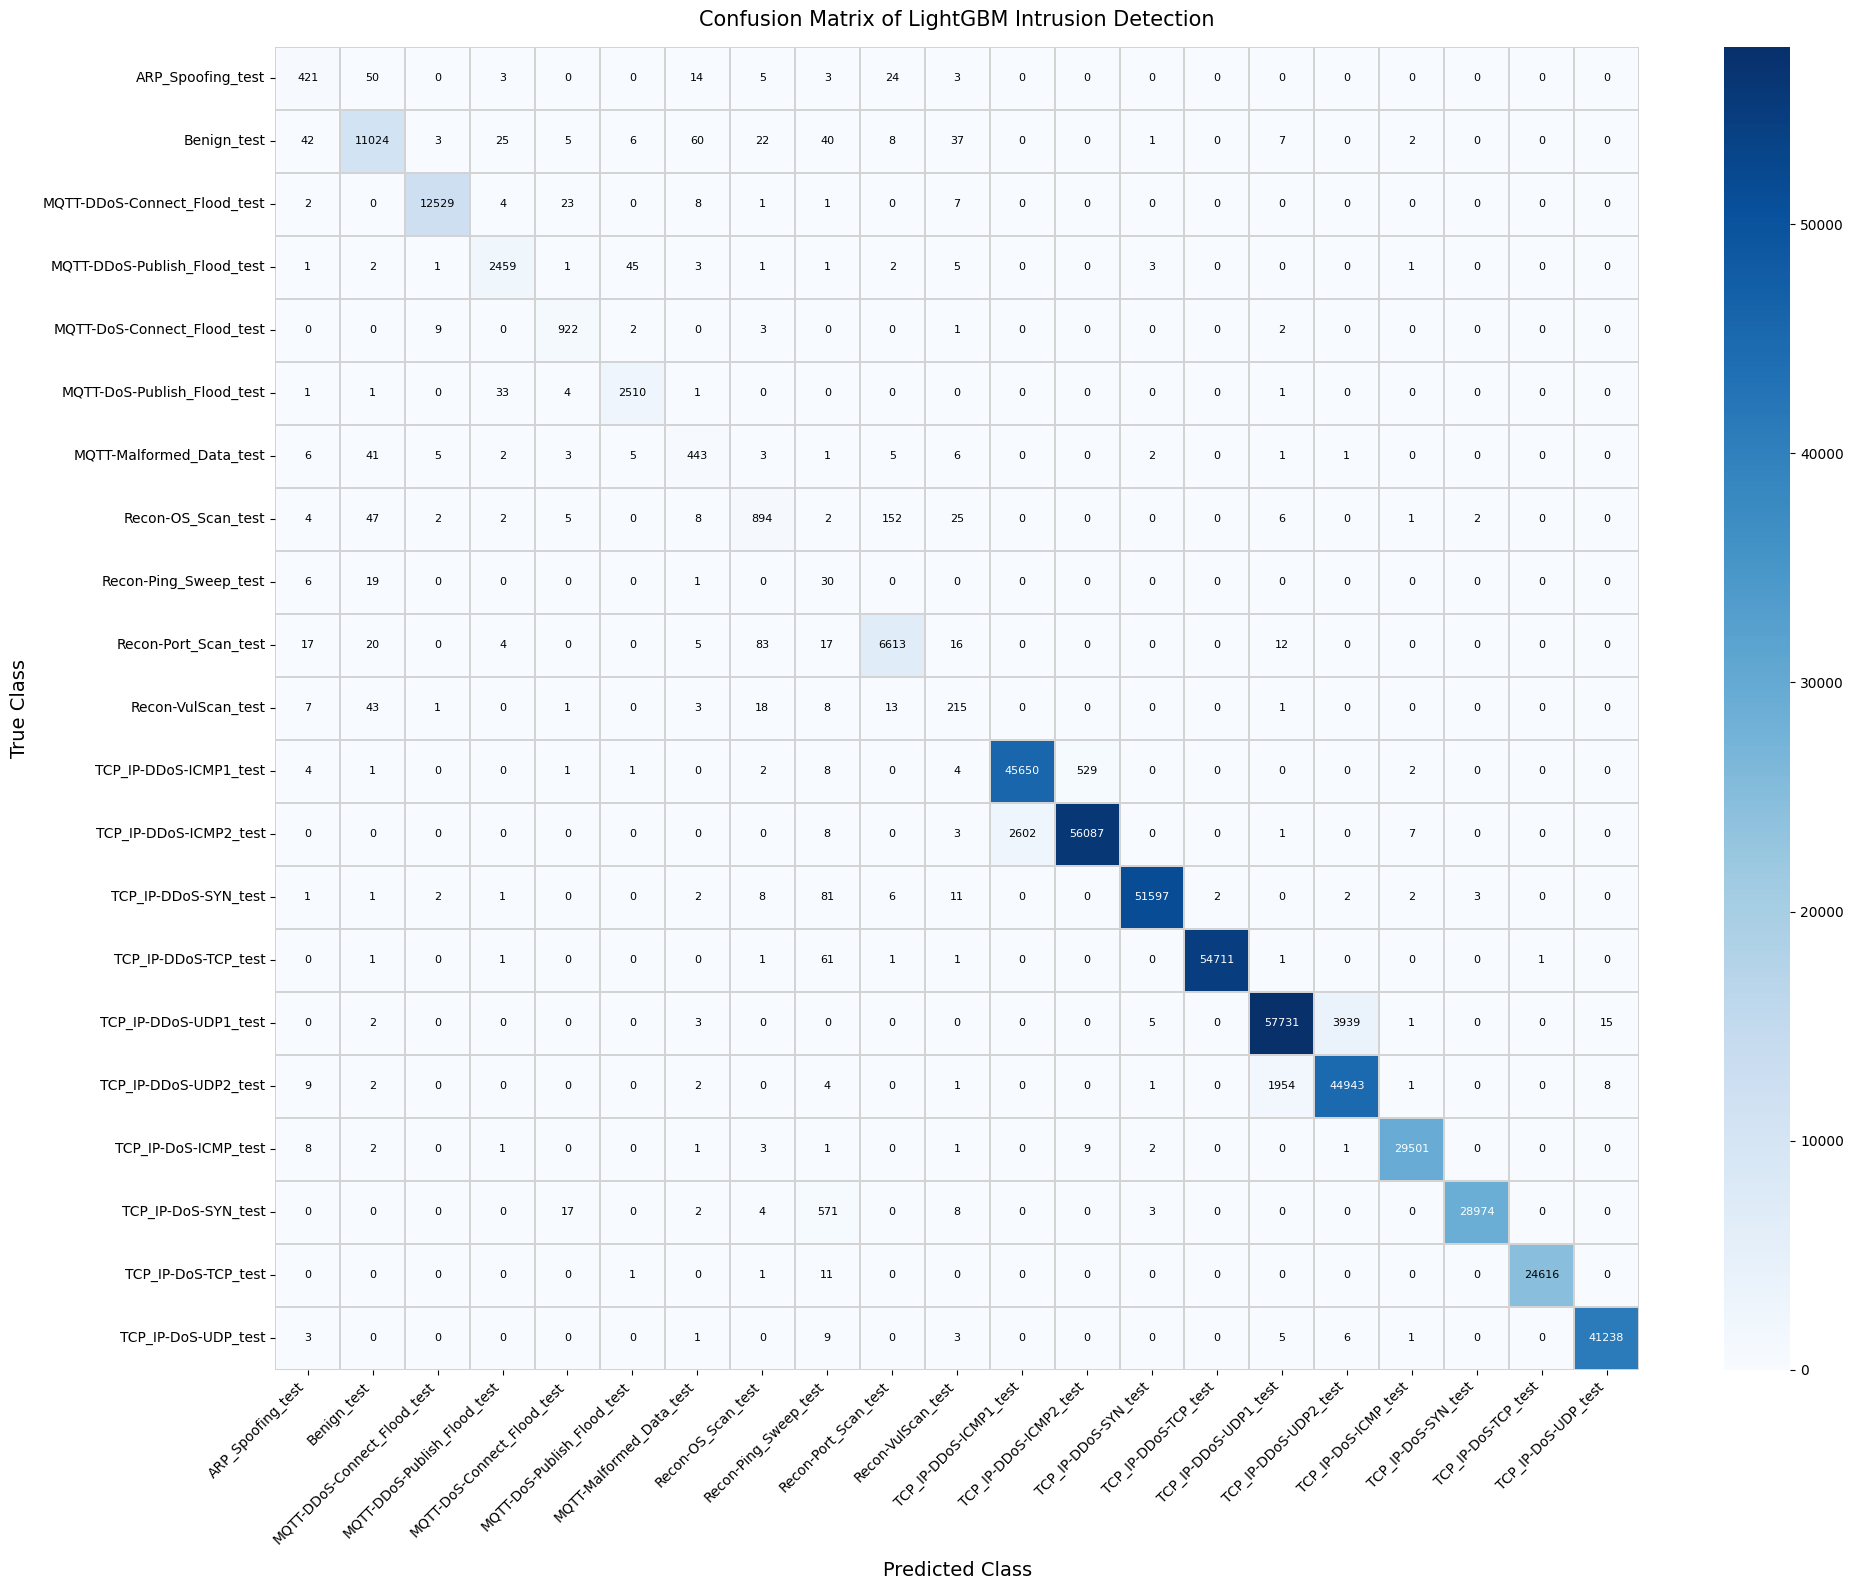

Saved: cm_lightgbm.png


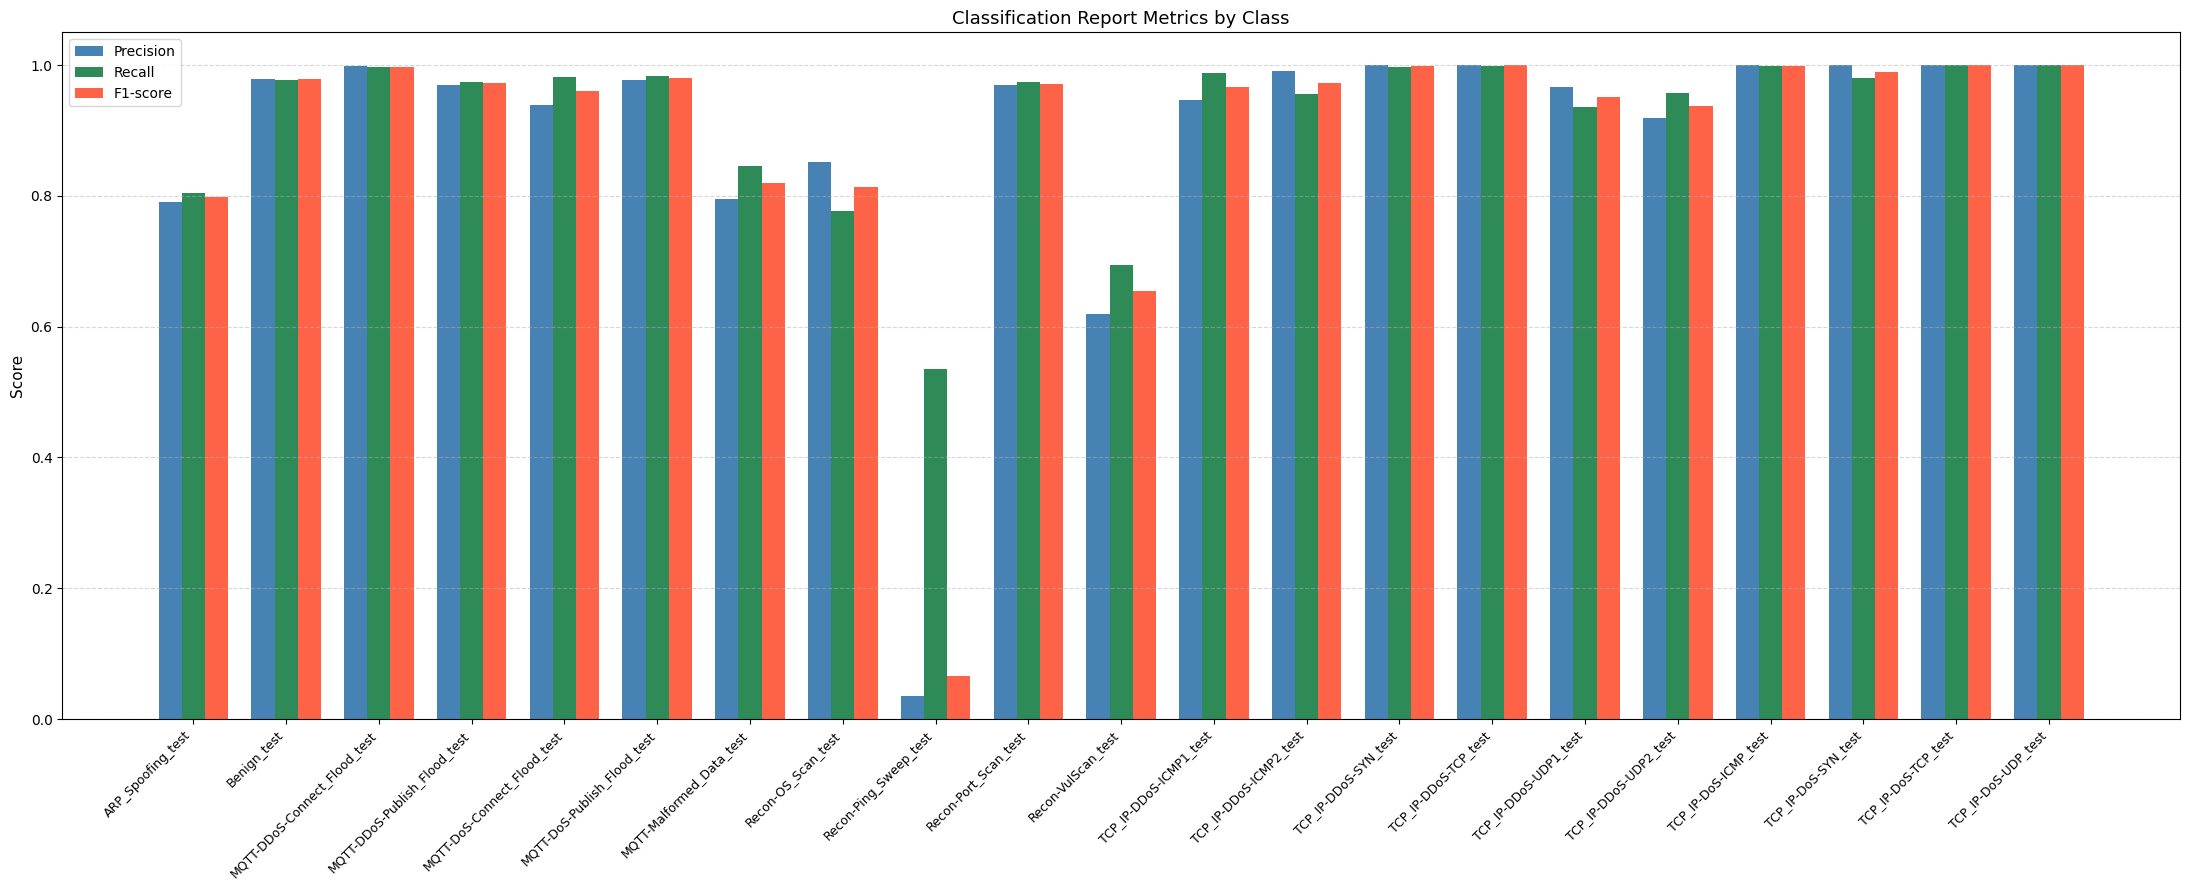

Saved: per_class_lightgbm.png


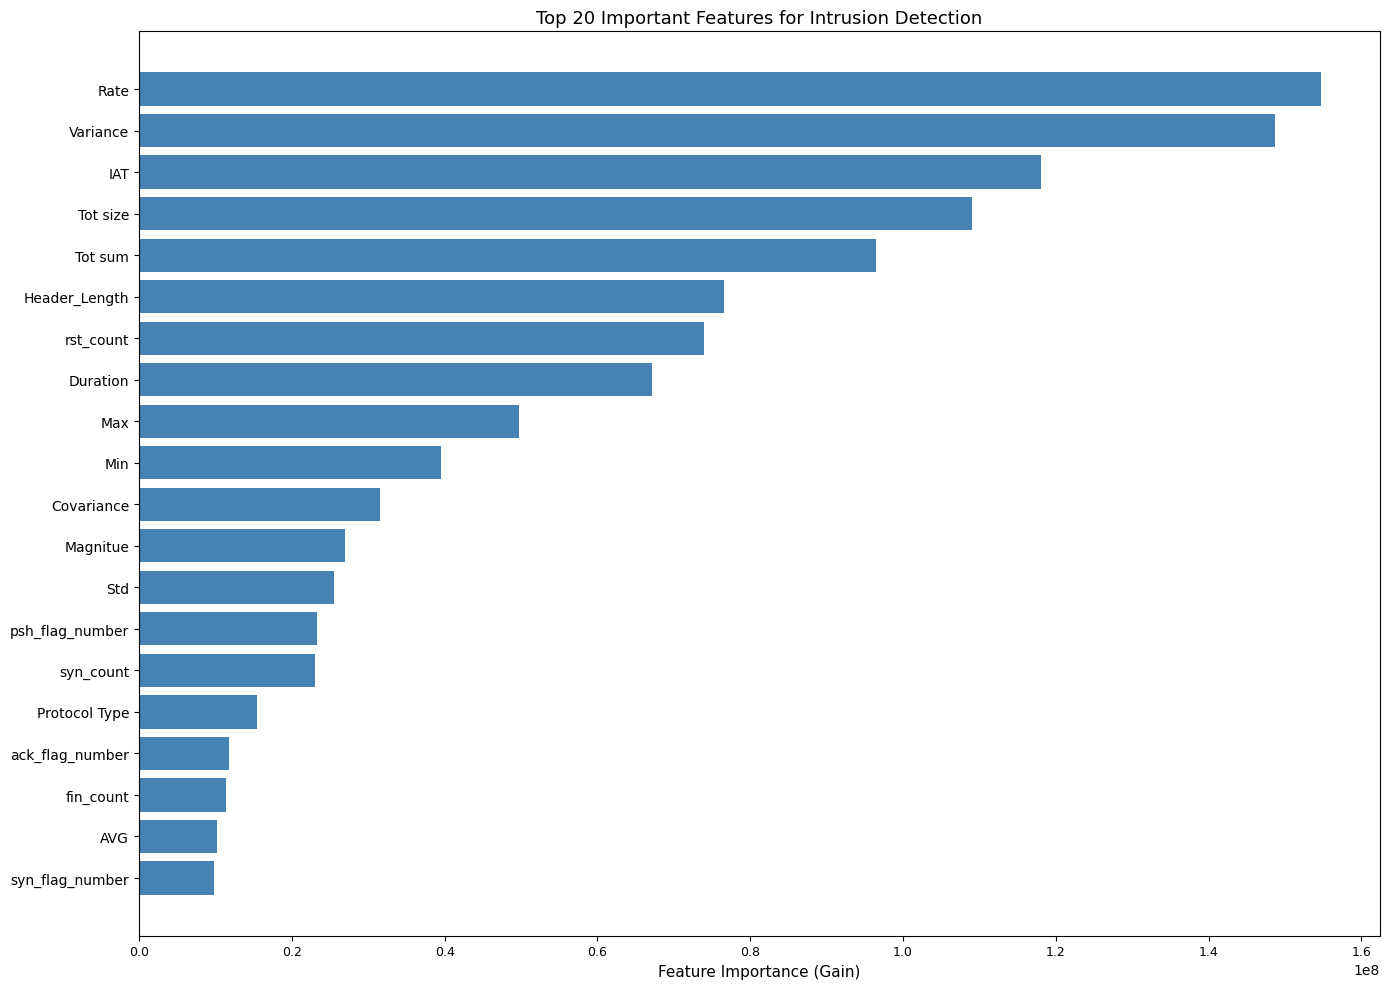

Saved: feature_importance_lightgbm.png


In [19]:
import lightgbm as lgb
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import time
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# ── 1. Load dataset ───────────────────────────────────────────────────────────
data_path = r"D:\Intensive Period\Review_IEEE_IoT\CIC_IoMT_2024_WiFi_MQTT_test.csv"
df = pd.read_csv(data_path)

df['Source_IP']      = df['Source_IP'].astype(str)
df['Destination_IP'] = df['Destination_IP'].astype(str)


# ── 2. Severity scores ────────────────────────────────────────────────────────
severity_scores = {
    'TCP_IP-DDoS-ICMP1_test':         10,
    'TCP_IP-DDoS-ICMP2_test':         10,
    'MQTT-DDoS-Connect_Flood_test':    9,
    'MQTT-DDoS-Publish_Flood_test':    9,
    'TCP_IP-DDoS-TCP_test':            9,
    'TCP_IP-DDoS-SYN_test':            9,
    'TCP_IP-DDoS-UDP1_test':           9,
    'TCP_IP-DDoS-UDP2_test':           9,
    'MQTT-DoS-Connect_Flood_test':     8,
    'MQTT-DoS-Publish_Flood_test':     8,
    'ARP_Spoofing_test':               7,
    'TCP_IP-DoS-ICMP_test':            7,
    'TCP_IP-DoS-SYN_test':             7,
    'TCP_IP-DoS-UDP_test':             7,
    'TCP_IP-DoS-TCP_test':             7,
    'Recon-VulScan_test':              6,
    'MQTT-Malformed_Data_test':        6,
    'Recon-OS_Scan_test':              5,
    'Recon-Port_Scan_test':            5,
    'Recon-OS_Sweep_test':             4,
    'Benign_test':                     0,
}

df['Severity_Score'] = df['label'].map(severity_scores).fillna(1).astype(int)


# ── 3. Feature / label split ──────────────────────────────────────────────────
drop_cols    = ['label', 'Severity_Score', 'Source_IP', 'Destination_IP']
feature_cols = [c for c in df.columns if c not in drop_cols]

X     = df[feature_cols].values
y_raw = df['label'].values

label_enc = LabelEncoder()
y_enc     = label_enc.fit_transform(y_raw)


# ── 4. Train / test split — 70/30 (stratified, seed=42) ──────────────────────
X_train, X_test, y_train, y_test_enc = train_test_split(
    X, y_enc, test_size=0.3, random_state=42, stratify=y_enc
)

print(f"Train : {X_train.shape[0]} samples (70%)")
print(f"Test  : {X_test.shape[0]} samples (30%)")


# ── 5. Scale features ─────────────────────────────────────────────────────────
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


# ── 6. LightGBM Datasets ──────────────────────────────────────────────────────
X_tr, X_v, y_tr, y_v = train_test_split(
    X_train_scaled, y_train, test_size=0.1,
    random_state=42, stratify=y_train
)
train_data = lgb.Dataset(X_tr, label=y_tr)
valid_data = lgb.Dataset(X_v,  label=y_v, reference=train_data)


# ── 7. Train & measure time ───────────────────────────────────────────────────
num_classes = len(label_enc.classes_)

params = {
    'objective':     'multiclass',
    'num_class':     num_classes,
    'metric':        'multi_logloss',
    'learning_rate': 0.05,
    'num_leaves':    31,
    'verbose':       -1,
}

t0 = time.perf_counter()
bst = lgb.train(
    params,
    train_data,
    valid_sets=[valid_data],
    num_boost_round=100,
    callbacks=[lgb.early_stopping(stopping_rounds=10),
               lgb.log_evaluation(-1)],
)
training_time = time.perf_counter() - t0
print(f"\nTraining Time: {training_time:.4f} seconds")


# ── 8. Inference ──────────────────────────────────────────────────────────────
t0          = time.perf_counter()
y_pred_prob = bst.predict(X_test_scaled)
infer_time  = time.perf_counter() - t0

y_pred = y_pred_prob.argmax(axis=1)

n_test_samples           = X_test_scaled.shape[0]
infer_time_per_sample_ms = (infer_time / n_test_samples) * 1000

print(f"Total Inference Time        : {infer_time:.4f} s  (on {n_test_samples} samples)")
print(f"Inference Time (per sample) : {infer_time_per_sample_ms:.6f} ms")


# ── 9. Model size & FLOPs ─────────────────────────────────────────────────────
model_file   = "lightgbm_model.txt"
bst.save_model(model_file)
model_size   = os.path.getsize(model_file) / (1024 * 1024)
num_trees    = bst.num_trees()
approx_flops = num_trees * params['num_leaves'] * 2

print(f"Model Size    : {model_size:.4f} MB")
print(f"Approx FLOPs  : {approx_flops} operations")


# ── 10. Classification report ─────────────────────────────────────────────────
print("\nLightGBM Classification Report:")
print(classification_report(y_test_enc, y_pred,
                            target_names=label_enc.classes_,
                            zero_division=0))


# ── Figure 1: Confusion Matrix — (20×16) → ~6000×4800 px ─────────────────────
cm = confusion_matrix(y_test_enc, y_pred)

fig, ax = plt.subplots(figsize=(20, 16))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    annot_kws={"size": 8},
    cmap="Blues",
    xticklabels=label_enc.classes_,
    yticklabels=label_enc.classes_,
    linewidths=0.3,
    linecolor="lightgrey",
    ax=ax,
    cbar=True,
)

max_val = cm.max()
for text_obj, val in zip(ax.texts, cm.flatten()):
    text_obj.set_color("white" if val > max_val * 0.5 else "black")

ax.set_xlabel("Predicted Class", fontsize=14, labelpad=10)
ax.set_ylabel("True Class", fontsize=14, labelpad=10)
ax.set_title("Confusion Matrix of LightGBM Intrusion Detection",
             fontsize=15, pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45,
                   ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('cm_lightgbm.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: cm_lightgbm.png")


# ── Figure 2: Per-class Precision, Recall, F1 — (22×9) → ~6600×2700 px ──────
report_dict = classification_report(y_test_enc, y_pred,
                                    target_names=label_enc.classes_,
                                    output_dict=True, zero_division=0)
classes    = label_enc.classes_
precisions = [report_dict[c]['precision'] for c in classes]
recalls    = [report_dict[c]['recall']    for c in classes]
f1s        = [report_dict[c]['f1-score']  for c in classes]

x = np.arange(len(classes))
w = 0.25

fig, ax = plt.subplots(figsize=(22, 9))
ax.bar(x - w, precisions, w, label='Precision', color='steelblue')
ax.bar(x,     recalls,    w, label='Recall',    color='seagreen')
ax.bar(x + w, f1s,        w, label='F1-score',  color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Classification Report Metrics by Class', fontsize=13)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('per_class_lightgbm.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: per_class_lightgbm.png")


# ── Figure 3: Top 20 Feature Importance — (14×10) → ~4200×3000 px ────────────
importance = bst.feature_importance(importance_type='gain')
feat_df    = pd.DataFrame({'feature': feature_cols, 'gain': importance})
feat_df    = feat_df.nlargest(20, 'gain').sort_values('gain')

fig, ax = plt.subplots(figsize=(14, 10))
ax.barh(feat_df['feature'], feat_df['gain'], color='steelblue')
ax.set_xlabel('Feature Importance (Gain)', fontsize=11)
ax.set_title('Top 20 Important Features for Intrusion Detection', fontsize=13)
ax.tick_params(axis='y', labelsize=10)
ax.tick_params(axis='x', labelsize=9)
plt.tight_layout()
plt.savefig('feature_importance_lightgbm.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: feature_importance_lightgbm.png")